# Professional Data Science Analysis: E-Commerce Transaction Dataset

**Objective:** Comprehensive exploratory data analysis, feature engineering, and predictive modeling

**Author:** Data Science Team  
**Date:** April 2026

---

## Table of Contents
1. [Data Loading & Initial Exploration](#section1)
2. [Data Information & Description](#section2)
3. [Missing Values & Data Quality](#section3)
4. [Exploratory Data Analysis](#section4)
5. [Data Distribution & Skewness](#section5)
6. [Outlier Detection & Analysis](#section6)
7. [Feature Engineering](#section7)
8. [Data Transformation](#section8)
9. [Predictive Modeling](#section9)
10. [Model Evaluation & Cross-Validation](#section10)
11. [Conclusions & Recommendations](#section11)

---
## 1. Data Loading & Initial Exploration <a id='section1'></a>

In [63]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# Statistical analysis
from scipy import stats
from scipy.stats import skew, kurtosis, normaltest

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully")
print(f"✓ Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Libraries imported successfully
✓ Analysis Date: 2026-04-08 16:53:18


In [64]:
# Load the dataset
# Note: Update the file path to match your dataset location
df = pd.read_csv('C:\\Users\\david\\OneDrive\\Desktop\\Transaction_Sales\\Sales Transaction.csv')  # Replace with actual file path

print("Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")

Dataset loaded successfully!

Dataset Shape: (536350, 8)
Total Records: 536,350
Total Features: 8


In [65]:
# First look at the data
print("=" * 80)
print("FIRST 10 ROWS")
print("=" * 80)
df.head(10)

FIRST 10 ROWS


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.470,12,17490.000,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.650,36,13069.000,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.530,12,13069.000,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.650,12,13069.000,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.940,6,13069.000,United Kingdom
5,581475,12/9/2019,21705,Bag 500g Swirly Marbles,10.650,24,13069.000,United Kingdom
6,581475,12/9/2019,22118,Joy Wooden Block Letters,11.530,18,13069.000,United Kingdom
7,581475,12/9/2019,22119,Peace Wooden Block Letters,12.250,12,13069.000,United Kingdom
8,581475,12/9/2019,22217,T-Light Holder Hanging Lace,10.650,12,13069.000,United Kingdom
9,581475,12/9/2019,22216,T-Light Holder White Lace,10.550,24,13069.000,United Kingdom


In [66]:
# Last rows
print("=" * 80)
print("LAST 10 ROWS")
print("=" * 80)
df.tail(10)

LAST 10 ROWS


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
536340,C536548,12/1/2018,22654,Deluxe Sewing Kit,16.350,-1,12472.000,Germany
536341,C536548,12/1/2018,22333,Retrospot Party Bag + Sticker Set,11.940,-1,12472.000,Germany
536342,C536548,12/1/2018,22245,Hook 1 Hanger Magic Garden,11.120,-2,12472.000,Germany
536343,C536548,12/1/2018,22077,6 Ribbons Rustic Charm,11.940,-6,12472.000,Germany
536344,C536548,12/1/2018,22631,Circus Parade Lunch Box,12.250,-1,12472.000,Germany
536345,C536548,12/1/2018,22168,Organiser Wood Antique White,18.960,-2,12472.000,Germany
536346,C536548,12/1/2018,21218,Red Spotty Biscuit Tin,14.090,-3,12472.000,Germany
536347,C536548,12/1/2018,20957,Porcelain Hanging Bell Small,11.740,-1,12472.000,Germany
536348,C536548,12/1/2018,22580,Advent Calendar Gingham Sack,16.350,-4,12472.000,Germany
536349,C536548,12/1/2018,22767,Triple Photo Frame Cornice,20.450,-2,12472.000,Germany


---
## 2. Data Information & Description <a id='section2'></a>

In [67]:
# Detailed data information
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  str    
 1   Date           536350 non-null  str    
 2   ProductNo      536350 non-null  str    
 3   ProductName    536350 non-null  str    
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 32.7 MB


In [68]:
# Data types summary
print("\n" + "=" * 80)
print("DATA TYPES SUMMARY")
print("=" * 80)
dtype_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.count().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df) * 100).round(2)
})
print(dtype_df.to_string(index=False))


DATA TYPES SUMMARY
       Column Data Type  Non-Null Count  Null Count  Null %
TransactionNo       str          536350           0   0.000
         Date       str          536350           0   0.000
    ProductNo       str          536350           0   0.000
  ProductName       str          536350           0   0.000
        Price   float64          536350           0   0.000
     Quantity     int64          536350           0   0.000
   CustomerNo   float64          536295          55   0.010
      Country       str          536350           0   0.000


In [69]:
# Statistical description for numerical features
print("\n" + "=" * 80)
print("NUMERICAL FEATURES - STATISTICAL DESCRIPTION")
print("=" * 80)
df.describe().T


NUMERICAL FEATURES - STATISTICAL DESCRIPTION


,count,mean,std,min,25%,50%,75%,max
Price,536350.000,12.662,8.490,5.130,10.990,11.940,14.090,660.620
Quantity,536350.000,9.919,216.662,-80995.000,1.000,3.000,10.000,80995.000
CustomerNo,536295.000,15227.893,1716.583,12004.000,13807.000,15152.000,16729.000,18287.000


In [70]:
# Statistical description for categorical features
print("\n" + "=" * 80)
print("CATEGORICAL FEATURES - STATISTICAL DESCRIPTION")
print("=" * 80)
df.describe(include='object').T


CATEGORICAL FEATURES - STATISTICAL DESCRIPTION


,count,unique,top,freq
TransactionNo,536350,23204,573585,1111
Date,536350,305,12/5/2019,5299
ProductNo,536350,3768,85123A,2378
ProductName,536350,3768,Cream Hanging Heart T-Light Holder,2378
Country,536350,38,United Kingdom,485095


---
## 3. Missing Values & Data Quality <a id='section3'></a>

In [71]:
# Missing values analysis
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100).round(2),
    'Data Type': df.dtypes.values,
}).sort_values('Missing %', ascending=False)

print(missing_df.to_string(index=False))
print(f"\nTotal Missing Values: {df.isnull().sum().sum():,}")
print(f"Percentage of Dataset: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")

MISSING VALUES ANALYSIS
       Column  Missing Count  Missing % Data Type
   CustomerNo             55      0.010   float64
TransactionNo              0      0.000       str
         Date              0      0.000       str
    ProductNo              0      0.000       str
  ProductName              0      0.000       str
        Price              0      0.000   float64
     Quantity              0      0.000     int64
      Country              0      0.000       str

Total Missing Values: 55
Percentage of Dataset: 0.00%


---
## 4. Exploratory Data Analysis <a id='section4'></a>

In [72]:
Data = df

In [73]:
Data.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.470,12,17490.000,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.650,36,13069.000,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.530,12,13069.000,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.650,12,13069.000,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.940,6,13069.000,United Kingdom


In [74]:
Data.isnull().sum()

TransactionNo     0
Date              0
ProductNo         0
ProductName       0
Price             0
Quantity          0
CustomerNo       55
Country           0
dtype: int64

In [75]:
# Convert Date column to datetime
Data['Date'] = pd.to_datetime(Data['Date'], errors='coerce')

# Create derived features for analysis
Data['TotalAmount'] = Data['Price'] * Data['Quantity']
Data['Year'] = Data['Date'].dt.year
Data['Month'] = Data['Date'].dt.month
Data['DayOfWeek'] = Data['Date'].dt.dayofweek
Data['Quarter'] = Data['Date'].dt.quarter

print("✓ Date features created successfully")

✓ Date features created successfully


Numerical Columns: ['Price', 'Quantity', 'CustomerNo', 'TotalAmount', 'Year', 'Month', 'DayOfWeek', 'Quarter']


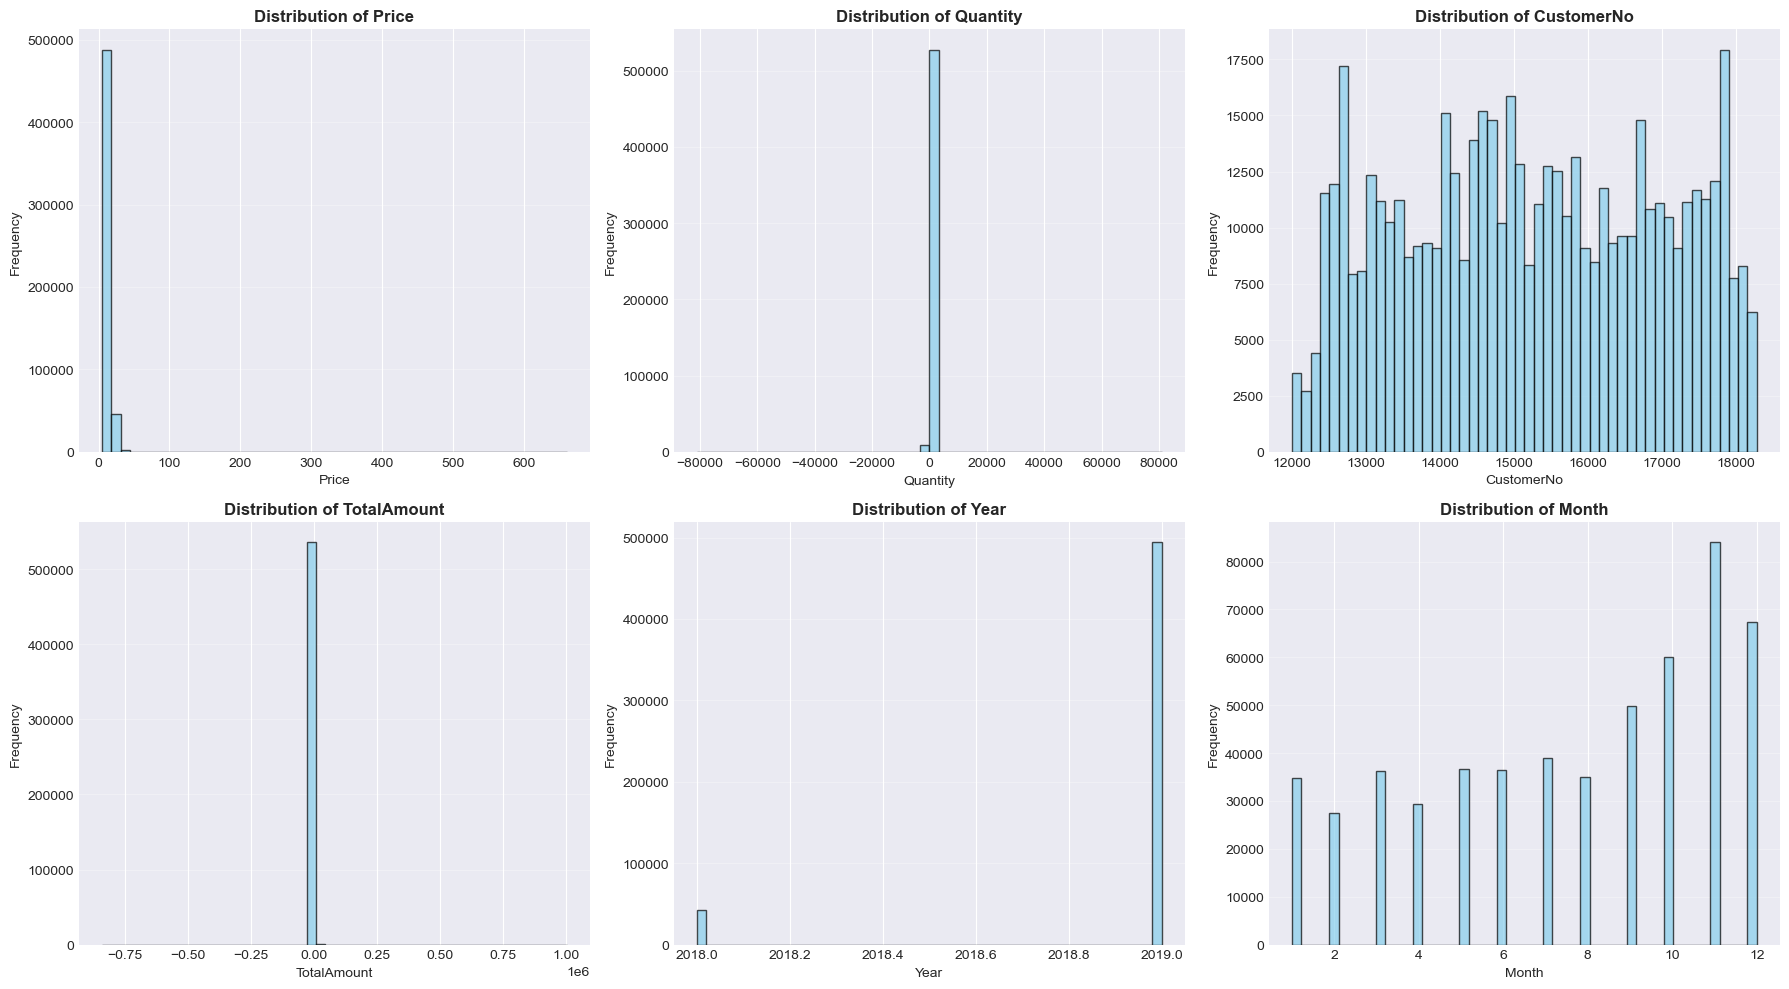

In [76]:
# Numerical features distribution
numerical_cols = Data.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical Columns: {numerical_cols}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:6]):
    axes[idx].hist(Data[col].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

TOP 15 COUNTRIES BY TRANSACTION COUNT
Country
United Kingdom    485095
Germany            10675
France             10526
EIRE                8048
Belgium             2539
Spain               2430
Switzerland         2336
Netherlands         2330
Portugal            1848
Australia           1704
Norway               938
Austria              887
Iceland              787
Finland              692
Italy                661
Name: count, dtype: int64


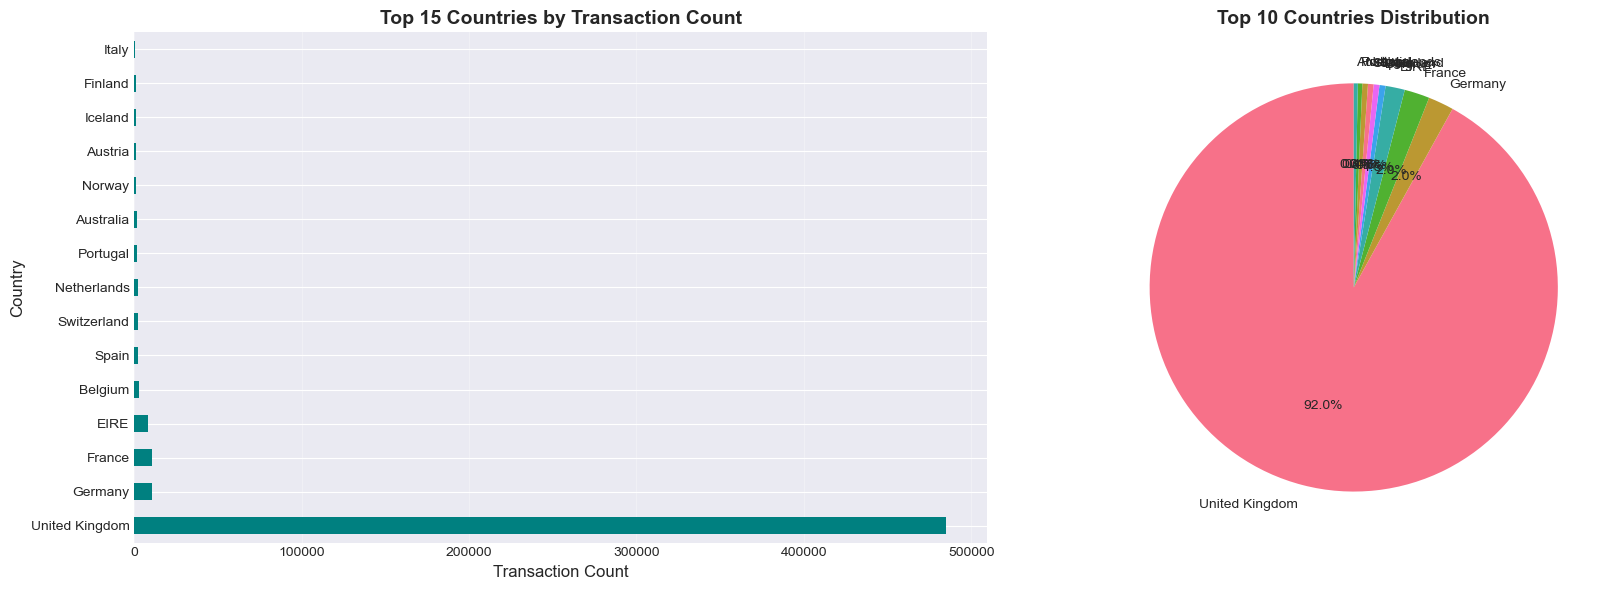

In [77]:
# Top countries by transaction count
print("=" * 80)
print("TOP 15 COUNTRIES BY TRANSACTION COUNT")
print("=" * 80)
country_counts = Data['Country'].value_counts().head(15)
print(country_counts)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar plot
country_counts.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 15 Countries by Transaction Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transaction Count', fontsize=12)
axes[0].set_ylabel('Country', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# Pie chart
country_counts.head(10).plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Top 10 Countries Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


TOP 15 PRODUCTS BY QUANTITY SOLD
ProductName
Popcorn Holder                        56450
World War 2 Gliders Asstd Designs     53847
Jumbo Bag Red Retrospot               47363
Assorted Colour Bird Ornament         36445
Pack Of 72 Retrospot Cake Cases       36231
Cream Hanging Heart T-Light Holder    35378
Rabbit Night Light                    30680
Mini Paint Set Vintage                26437
Pack Of 12 London Tissues             25907
Pack Of 60 Pink Paisley Cake Cases    24753
Victorian Glass Hanging T-Light       23854
Assorted Colours Silk Fan             23082
Brocade Ring Purse                    23053
Red Harmonica In Box                  21874
Jumbo Bag Pink Polkadot               21009
Name: Quantity, dtype: int64


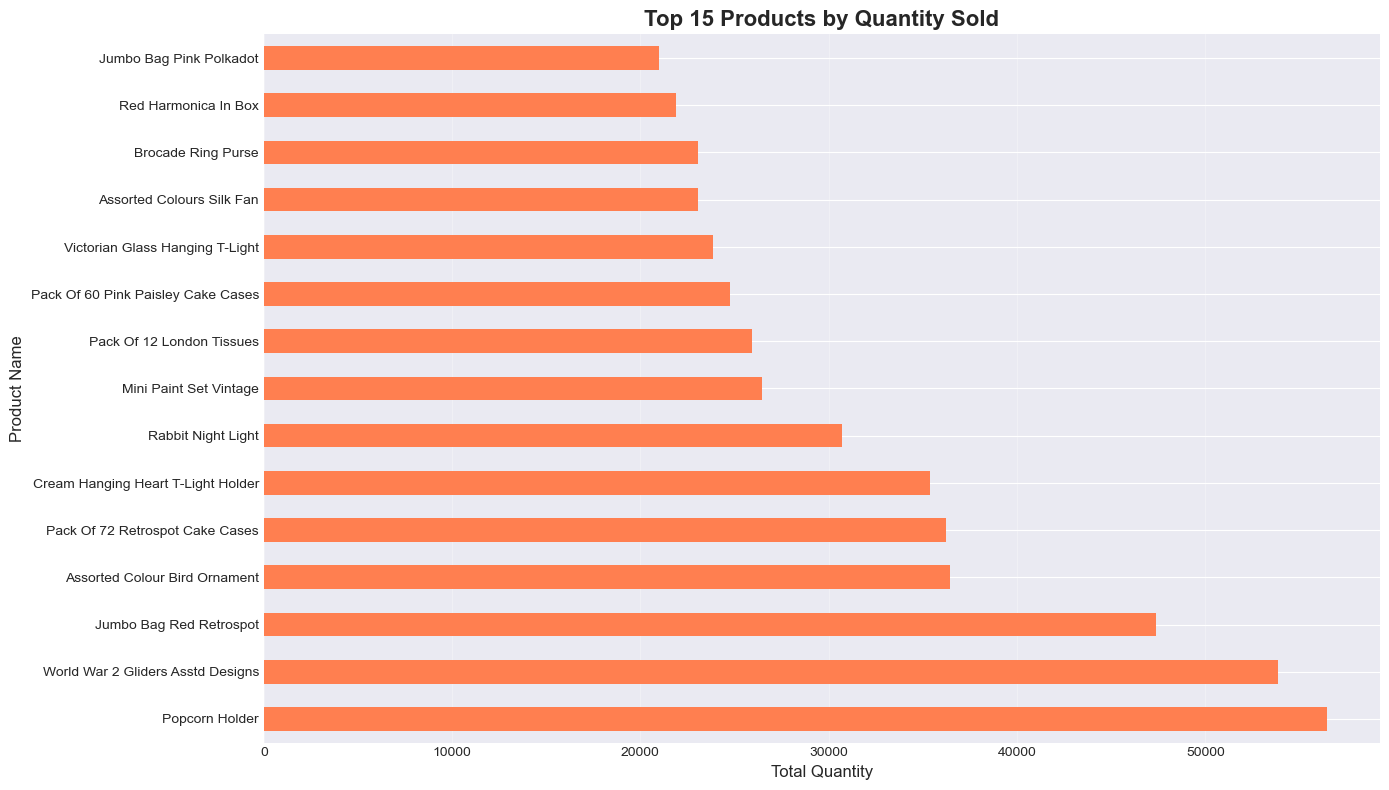

In [78]:
# Top products analysis
print("\n" + "=" * 80)
print("TOP 15 PRODUCTS BY QUANTITY SOLD")
print("=" * 80)
product_qty = Data.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(15)
print(product_qty)

# Visualization
plt.figure(figsize=(14, 8))
product_qty.plot(kind='barh', color='coral')
plt.title('Top 15 Products by Quantity Sold', fontsize=16, fontweight='bold')
plt.xlabel('Total Quantity', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


TOP 15 COUNTRIES BY REVENUE
Country
United Kingdom   49994030.170
Netherlands       2147811.390
EIRE              1660645.070
Germany           1350265.400
France            1316880.980
Australia          988756.350
Sweden             396042.610
Switzerland        358423.610
Japan              283293.470
Belgium            271346.980
Spain              265738.800
Norway             187544.790
Portugal           175269.450
Finland            120597.860
Denmark            100439.120
Name: TotalAmount, dtype: float64


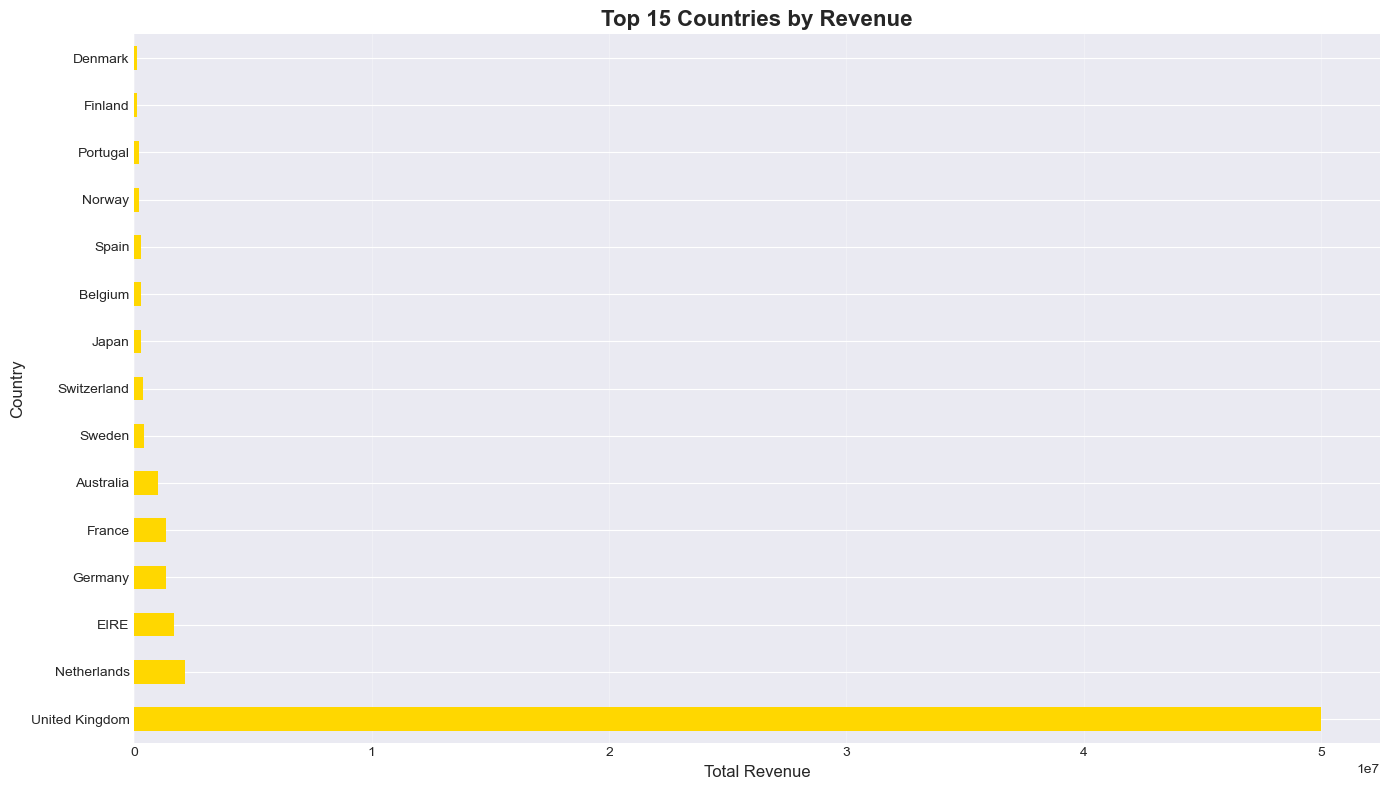

In [79]:
# Revenue analysis by country
print("\n" + "=" * 80)
print("TOP 15 COUNTRIES BY REVENUE")
print("=" * 80)
country_revenue = Data.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(15)
print(country_revenue)

# Visualization
plt.figure(figsize=(14, 8))
country_revenue.plot(kind='barh', color='gold')
plt.title('Top 15 Countries by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

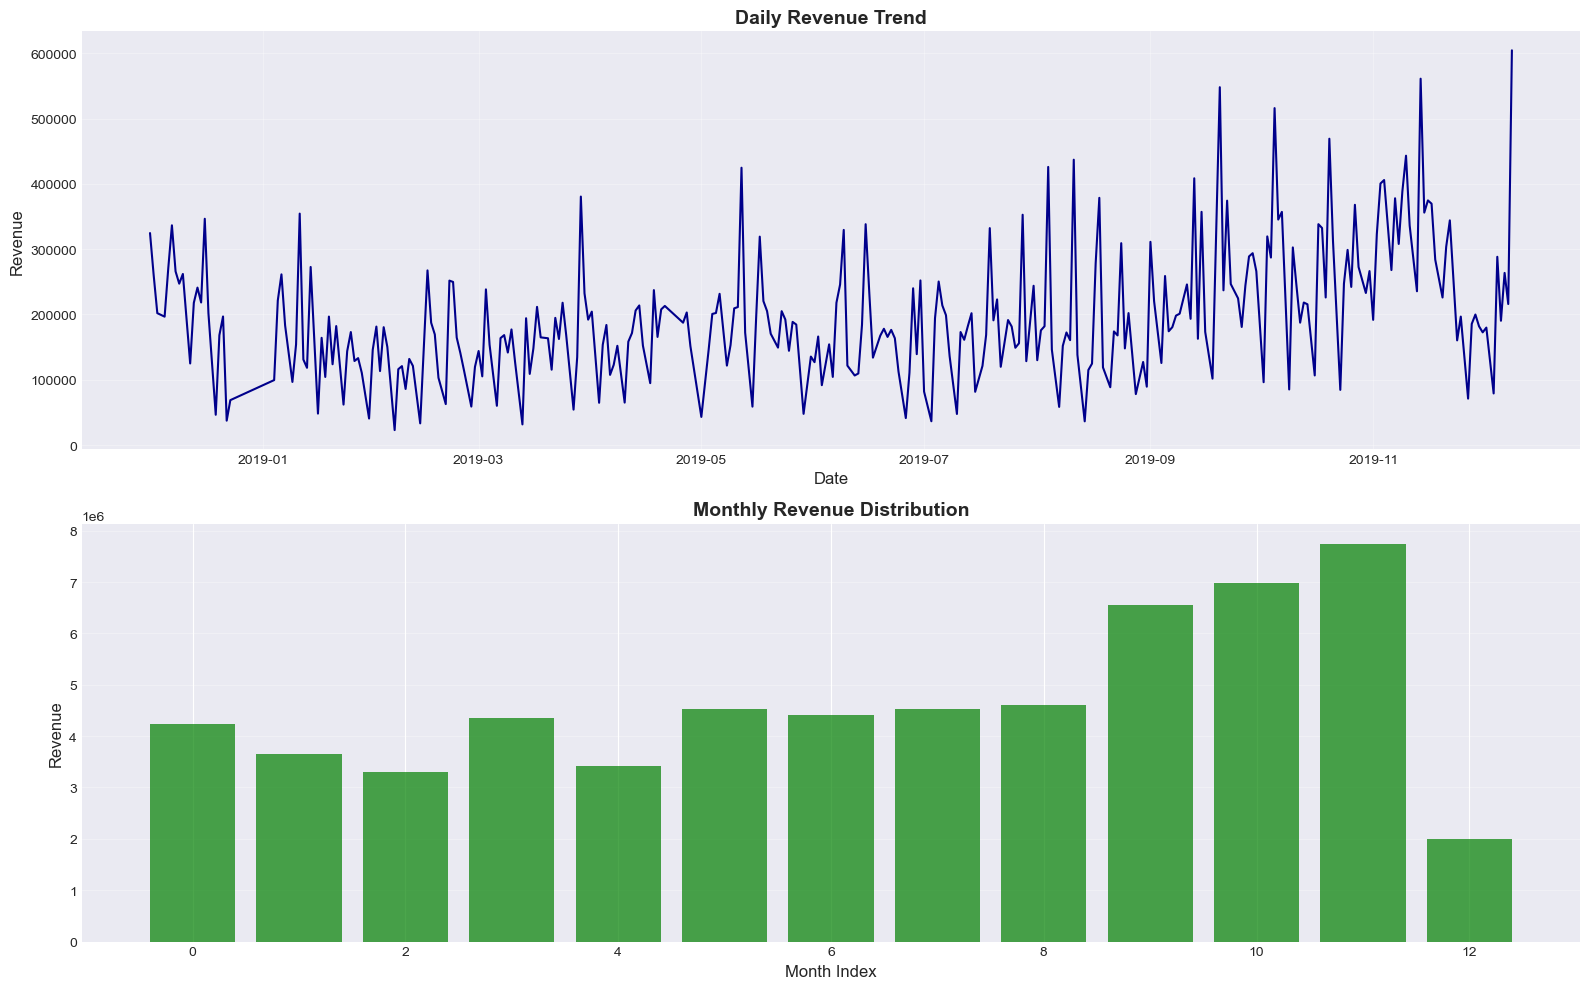

In [80]:
# Time series analysis
if 'Date' in Data.columns:
    daily_sales = Data.groupby(Data['Date'].dt.date)['TotalAmount'].sum()
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # Daily revenue trend
    axes[0].plot(daily_sales.index, daily_sales.values, color='darkblue', linewidth=1.5)
    axes[0].set_title('Daily Revenue Trend', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Date', fontsize=12)
    axes[0].set_ylabel('Revenue', fontsize=12)
    axes[0].grid(alpha=0.3)
    
    # Monthly revenue
    monthly_sales = Data.groupby([Data['Date'].dt.year, Data['Date'].dt.month])['TotalAmount'].sum()
    axes[1].bar(range(len(monthly_sales)), monthly_sales.values, color='green', alpha=0.7)
    axes[1].set_title('Monthly Revenue Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Month Index', fontsize=12)
    axes[1].set_ylabel('Revenue', fontsize=12)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

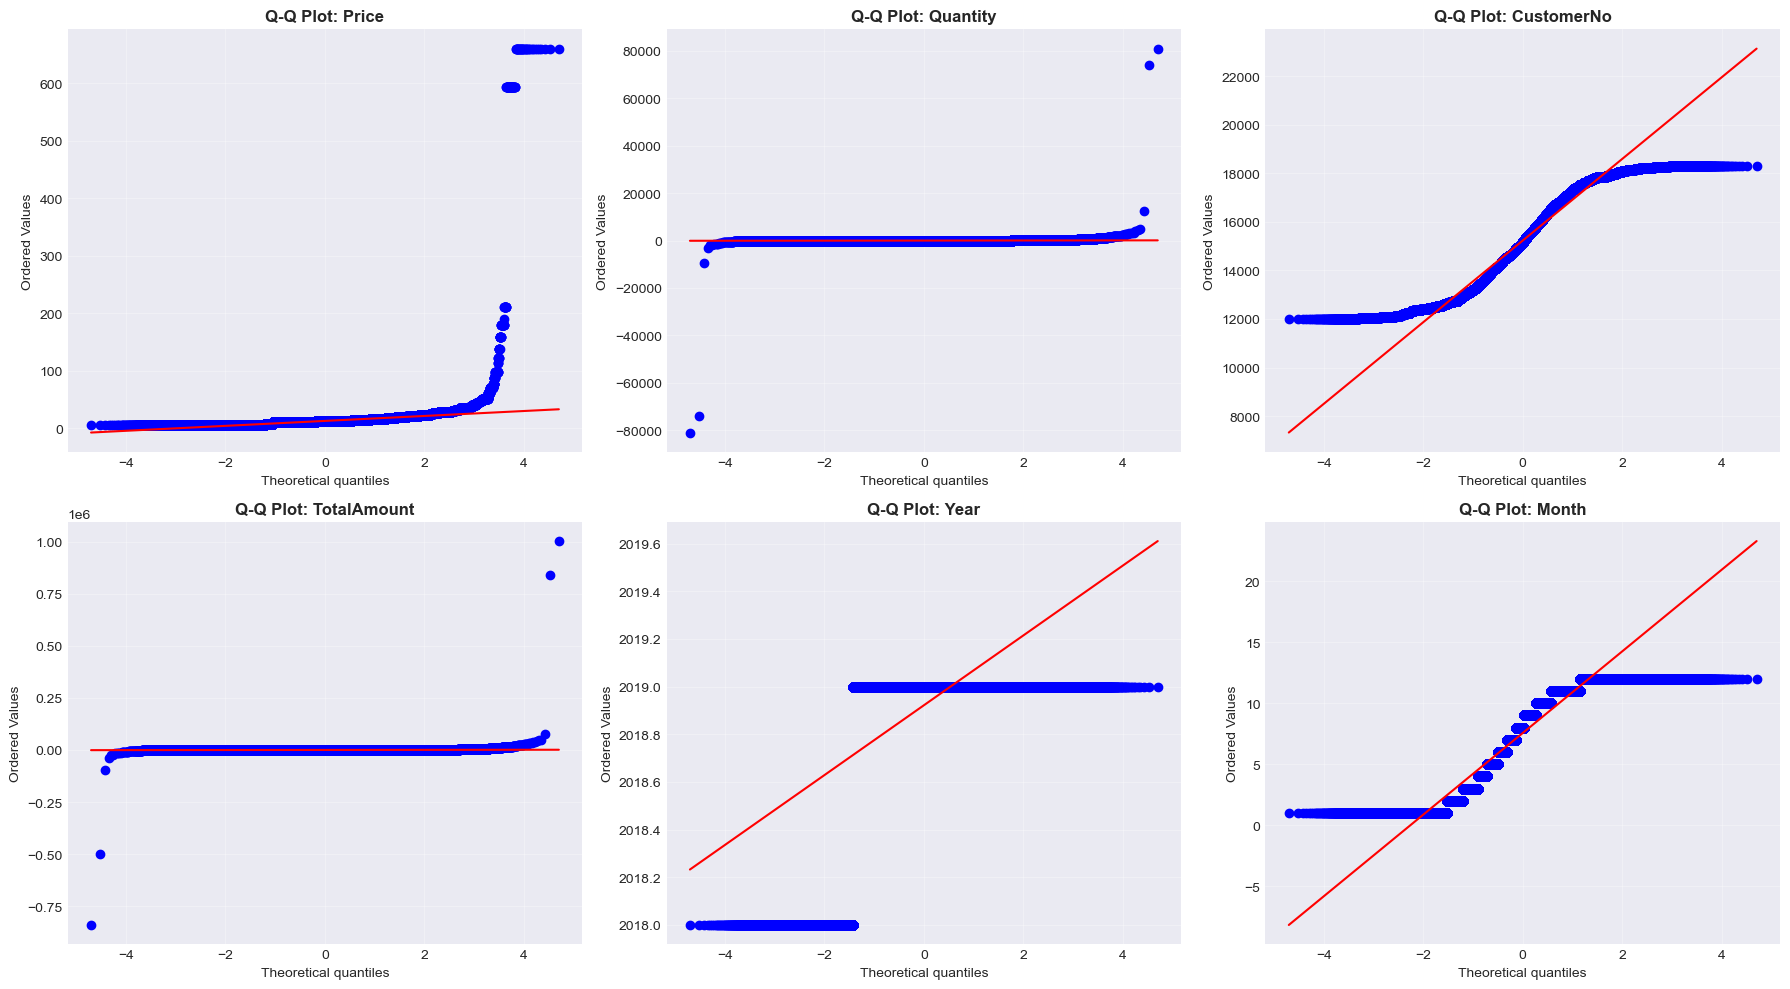

In [81]:
# Q-Q plots for normality assessment
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:6]):
    stats.probplot(Data[col].dropna(), dist="norm", plot=axes[idx])
    axes[idx].set_title(f'Q-Q Plot: {col}', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Outlier Detection & Analysis <a id='section6'></a>

In [82]:
# Outlier detection using IQR method
print("=" * 80)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 80)

def detect_outliers_iqr(Data, column):
    """Detect outliers using Interquartile Range method"""
    Q1 = Data[column].quantile(0.25)
    Q3 = Data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = Data[(Data[column] < lower_bound) | (Data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outlier_summary = []
for col in numerical_cols:
    outliers, lower, upper = detect_outliers_iqr(Data, col)
    outlier_summary.append({
        'Feature': col,
        'Outlier Count': len(outliers),
        'Outlier %': (len(outliers) / len(Data) * 100),
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Min': Data[col].min(),
        'Max': Data[col].max()
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
print(outlier_df.to_string(index=False))

OUTLIER DETECTION (IQR Method)
    Feature  Outlier Count  Outlier %  Lower Bound  Upper Bound         Min         Max
      Price          99142     18.485        6.340       18.740       5.130     660.620
   Quantity          57371     10.697      -12.500       23.500  -80995.000   80995.000
TotalAmount          44819      8.356     -133.550      265.730 -840113.800 1002718.100
       Year          42094      7.848     2019.000     2019.000    2018.000    2019.000
 CustomerNo              0      0.000     9424.000    21112.000   12004.000   18287.000
      Month              0      0.000       -4.000       20.000       1.000      12.000
  DayOfWeek              0      0.000       -2.500        9.500       0.000       6.000
    Quarter              0      0.000       -1.000        7.000       1.000       4.000


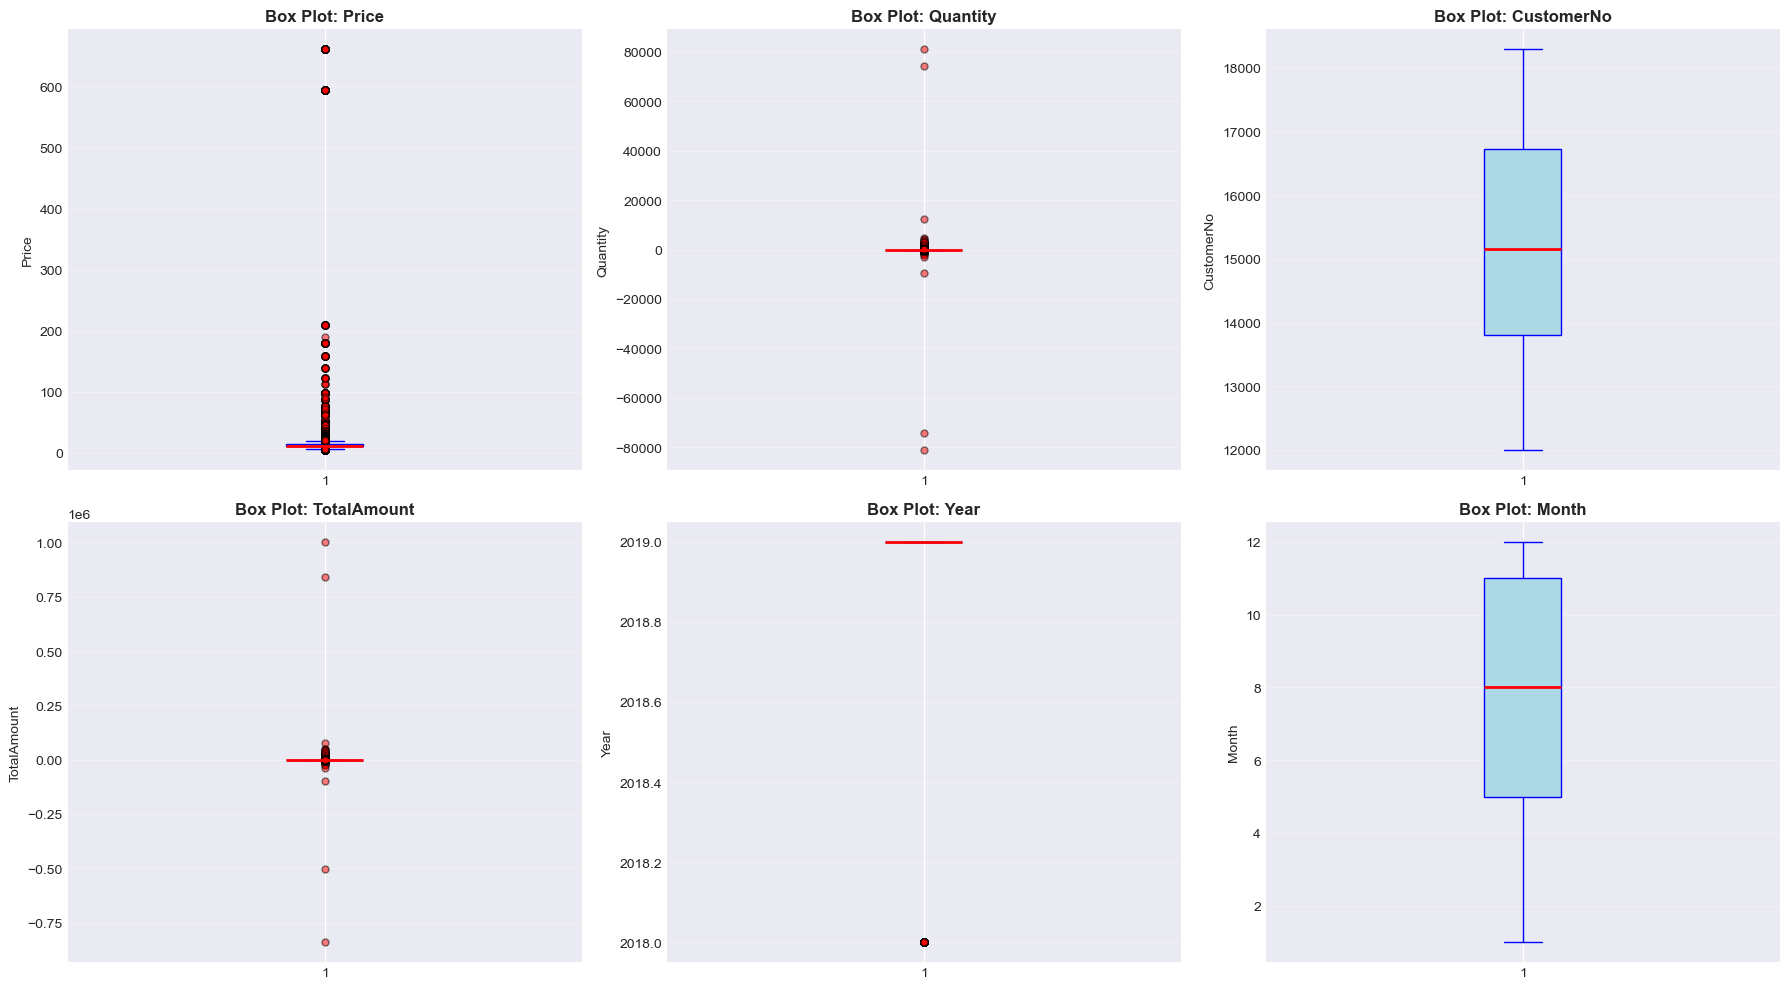

In [83]:
# Box plots for outlier visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:6]):
    bp = axes[idx].boxplot(Data[col].dropna(), vert=True, patch_artist=True,
                           boxprops=dict(facecolor='lightblue', color='blue'),
                           whiskerprops=dict(color='blue'),
                           capprops=dict(color='blue'),
                           medianprops=dict(color='red', linewidth=2),
                           flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))
    
    axes[idx].set_title(f'Box Plot: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

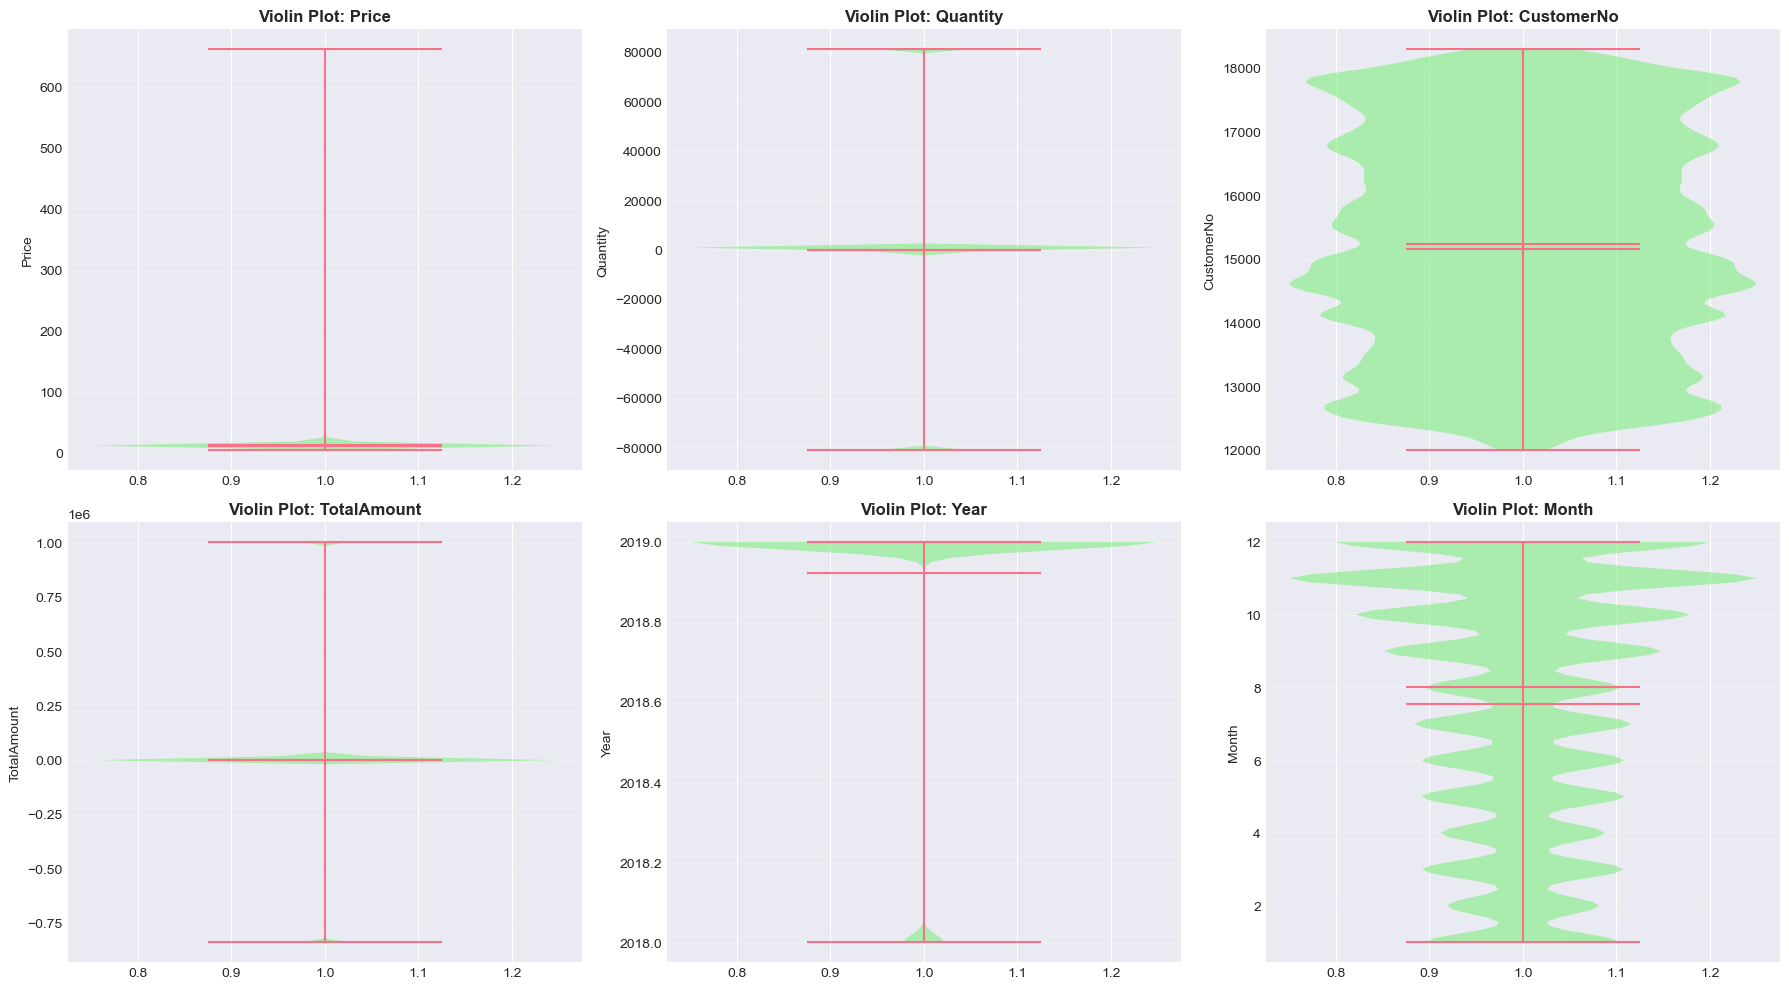

In [84]:
# Violin plots for outlier visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:6]):
    parts = axes[idx].violinplot([Data[col].dropna()], vert=True, showmeans=True, showmedians=True)
    
    # Customize colors
    for pc in parts['bodies']:
        pc.set_facecolor('lightgreen')
        pc.set_alpha(0.7)
    
    axes[idx].set_title(f'Violin Plot: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

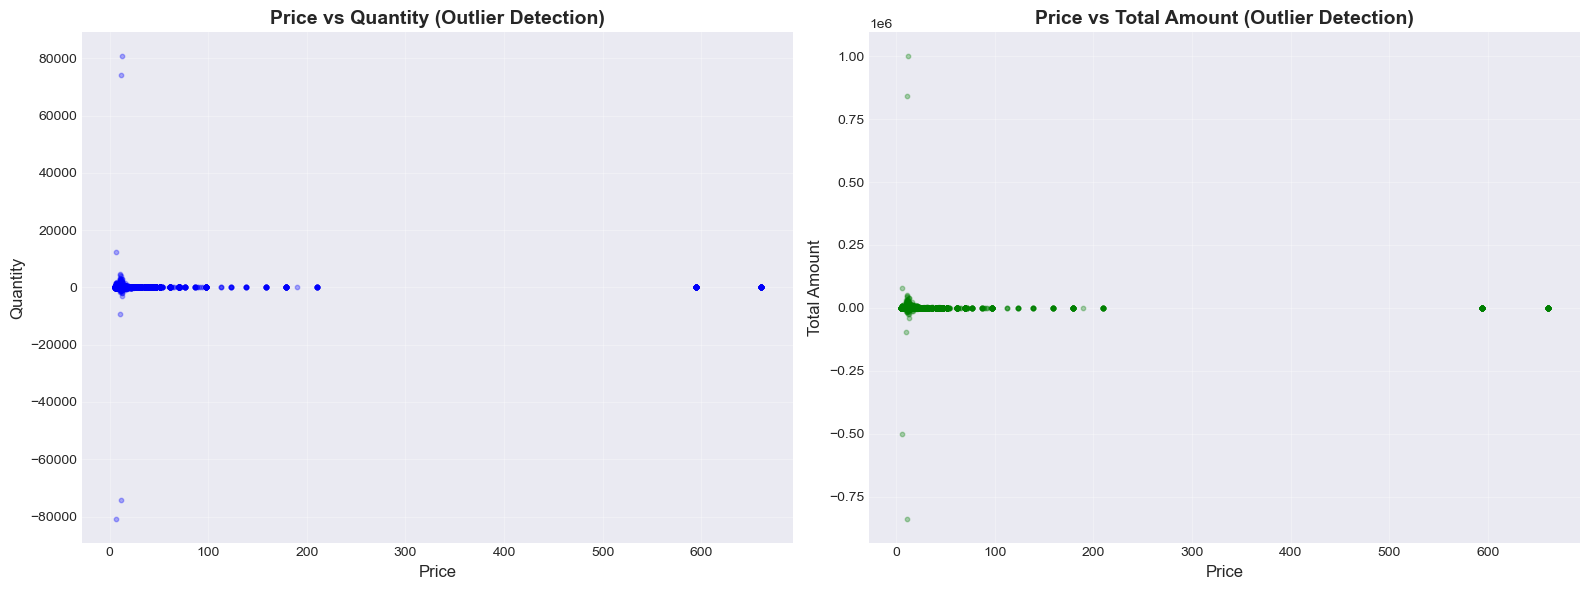

In [85]:
# Scatter plots to identify multivariate outliers
if len(numerical_cols) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Price vs Quantity
    axes[0].scatter(Data['Price'], Data['Quantity'], alpha=0.3, s=10, c='blue')
    axes[0].set_title('Price vs Quantity (Outlier Detection)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Price', fontsize=12)
    axes[0].set_ylabel('Quantity', fontsize=12)
    axes[0].grid(alpha=0.3)
    
    # Price vs TotalAmount
    axes[1].scatter(Data['Price'], Data['TotalAmount'], alpha=0.3, s=10, c='green')
    axes[1].set_title('Price vs Total Amount (Outlier Detection)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Price', fontsize=12)
    axes[1].set_ylabel('Total Amount', fontsize=12)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

---
## 7. Feature Engineering <a id='section7'></a>

In [86]:
# Create a copy for feature engineering
df_fe = Data.copy()

print("=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

# 1. Customer-based features
customer_features = df_fe.groupby('CustomerNo').agg({
    'TransactionNo': 'count',
    'TotalAmount': ['sum', 'mean', 'std'],
    'Quantity': ['sum', 'mean'],
    'Price': ['mean', 'max', 'min']
}).reset_index()

customer_features.columns = ['CustomerNo', 'TotalTransactions', 'TotalRevenue', 
                              'AvgRevenue', 'StdRevenue', 'TotalQuantity', 
                              'AvgQuantity', 'AvgPrice', 'MaxPrice', 'MinPrice']

# 2. Product-based features
product_features = df_fe.groupby('ProductNo').agg({
    'TransactionNo': 'count',
    'Quantity': 'sum',
    'Price': 'mean'
}).reset_index()

product_features.columns = ['ProductNo', 'ProductTransactions', 'ProductQuantitySold', 'ProductAvgPrice']

# 3. Time-based features (already created)
df_fe['IsWeekend'] = df_fe['DayOfWeek'].isin([5, 6]).astype(int)
df_fe['Hour'] = df_fe['Date'].dt.hour
df_fe['DayOfMonth'] = df_fe['Date'].dt.day

# 4. Transaction-based features
df_fe['PricePerUnit'] = df_fe['TotalAmount'] / df_fe['Quantity'].replace(0, 1)
df_fe['IsReturn'] = (df_fe['Quantity'] < 0).astype(int)
df_fe['HighValue'] = (df_fe['TotalAmount'] > df_fe['TotalAmount'].quantile(0.75)).astype(int)

# Merge features
df_fe = df_fe.merge(customer_features, on='CustomerNo', how='left')
df_fe = df_fe.merge(product_features, on='ProductNo', how='left')

print(f"✓ Created {len(customer_features.columns) + len(product_features.columns) - 2} new features")
print(f"✓ New shape: {df_fe.shape}")
print("\nNew Features Created:")
new_features = ['TotalTransactions', 'TotalRevenue', 'AvgRevenue', 'StdRevenue',
                'TotalQuantity', 'AvgQuantity', 'AvgPrice', 'MaxPrice', 'MinPrice',
                'ProductTransactions', 'ProductQuantitySold', 'ProductAvgPrice',
                'IsWeekend', 'Hour', 'DayOfMonth', 'PricePerUnit', 'IsReturn', 'HighValue']
for i, feat in enumerate(new_features, 1):
    print(f"{i}. {feat}")

FEATURE ENGINEERING
✓ Created 12 new features
✓ New shape: (536350, 31)

New Features Created:
1. TotalTransactions
2. TotalRevenue
3. AvgRevenue
4. StdRevenue
5. TotalQuantity
6. AvgQuantity
7. AvgPrice
8. MaxPrice
9. MinPrice
10. ProductTransactions
11. ProductQuantitySold
12. ProductAvgPrice
13. IsWeekend
14. Hour
15. DayOfMonth
16. PricePerUnit
17. IsReturn
18. HighValue


In [87]:
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   TransactionNo        536350 non-null  str           
 1   Date                 536350 non-null  datetime64[us]
 2   ProductNo            536350 non-null  str           
 3   ProductName          536350 non-null  str           
 4   Price                536350 non-null  float64       
 5   Quantity             536350 non-null  int64         
 6   CustomerNo           536295 non-null  float64       
 7   Country              536350 non-null  str           
 8   TotalAmount          536350 non-null  float64       
 9   Year                 536350 non-null  int32         
 10  Month                536350 non-null  int32         
 11  DayOfWeek            536350 non-null  int32         
 12  Quarter              536350 non-null  int32         
 13  IsWeekend            5363


CORRELATION ANALYSIS


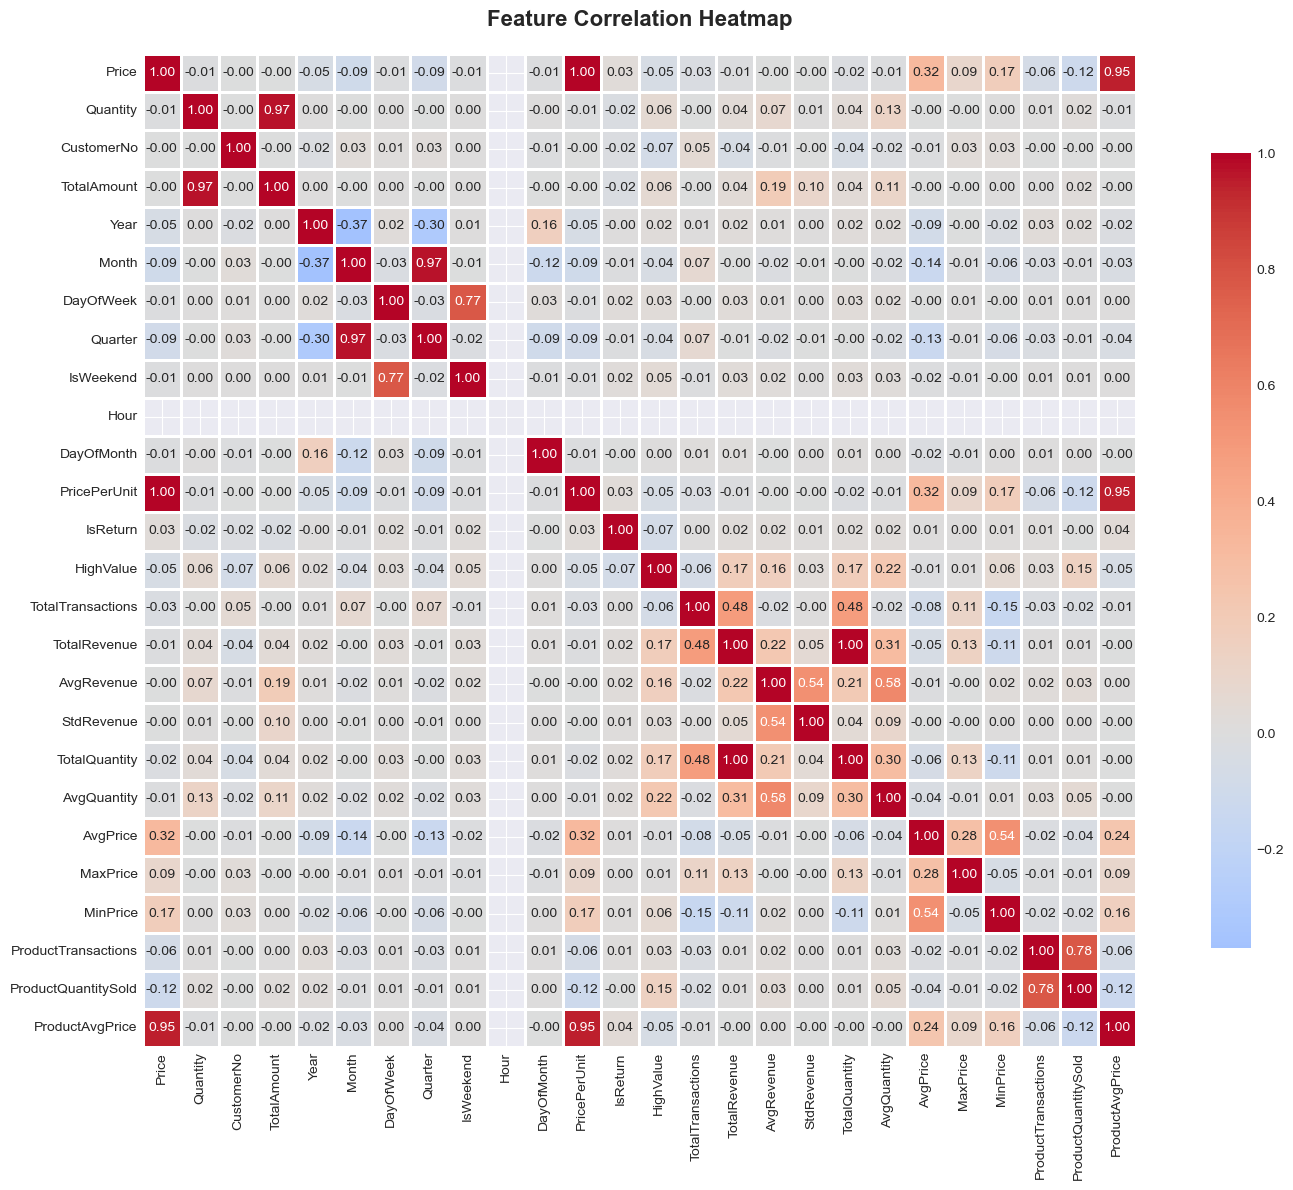


Highly Correlated Features (|r| > 0.7):
          Feature 1           Feature 2  Correlation
              Price        PricePerUnit        1.000
       TotalRevenue       TotalQuantity        0.998
              Month             Quarter        0.973
           Quantity         TotalAmount        0.971
              Price     ProductAvgPrice        0.951
       PricePerUnit     ProductAvgPrice        0.951
ProductTransactions ProductQuantitySold        0.777
          DayOfWeek           IsWeekend        0.774


In [88]:
# Correlation analysis
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Select numerical columns for correlation
corr_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df_fe[corr_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# High correlations
print("\nHighly Correlated Features (|r| > 0.7):")
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', ascending=False, key=abs)
    print(high_corr_df.to_string(index=False))
else:
    print("No highly correlated features found.")

---
## 8. Data Transformation <a id='section8'></a>

In [89]:
print("=" * 80)
print("DATA TRANSFORMATION")
print("=" * 80)

# Handle missing values
print("\n1. Handling Missing Values...")
df_transformed = df_fe.copy()

# Fill missing CustomerNo with a placeholder
df_transformed['CustomerNo'].fillna(-1, inplace=True)

# Fill missing numerical features with median
for col in df_transformed.select_dtypes(include=[np.number]).columns:
    if df_transformed[col].isnull().sum() > 0:
        df_transformed[col].fillna(df_transformed[col].median(), inplace=True)

print(f"   ✓ Missing values handled")
print(f"   ✓ Remaining missing values: {df_transformed.isnull().sum().sum()}")

# Log transformation for highly skewed features
print("\n2. Applying Log Transformation to Skewed Features...")
skewed_features = ['Price', 'Quantity', 'TotalAmount']

for col in skewed_features:
    if col in df_transformed.columns:
        # Add 1 to handle zero values
        df_transformed[f'{col}_log'] = np.log1p(df_transformed[col].clip(lower=0))
        print(f"   ✓ Created {col}_log")

# Square root transformation
print("\n3. Applying Square Root Transformation...")
for col in ['TotalAmount', 'Quantity']:
    if col in df_transformed.columns:
        df_transformed[f'{col}_sqrt'] = np.sqrt(df_transformed[col].clip(lower=0))
        print(f"   ✓ Created {col}_sqrt")

print(f"\n✓ Transformation complete. New shape: {df_transformed.shape}")

DATA TRANSFORMATION

1. Handling Missing Values...
   ✓ Missing values handled
   ✓ Remaining missing values: 652

2. Applying Log Transformation to Skewed Features...
   ✓ Created Price_log
   ✓ Created Quantity_log
   ✓ Created TotalAmount_log

3. Applying Square Root Transformation...
   ✓ Created TotalAmount_sqrt
   ✓ Created Quantity_sqrt

✓ Transformation complete. New shape: (536350, 36)


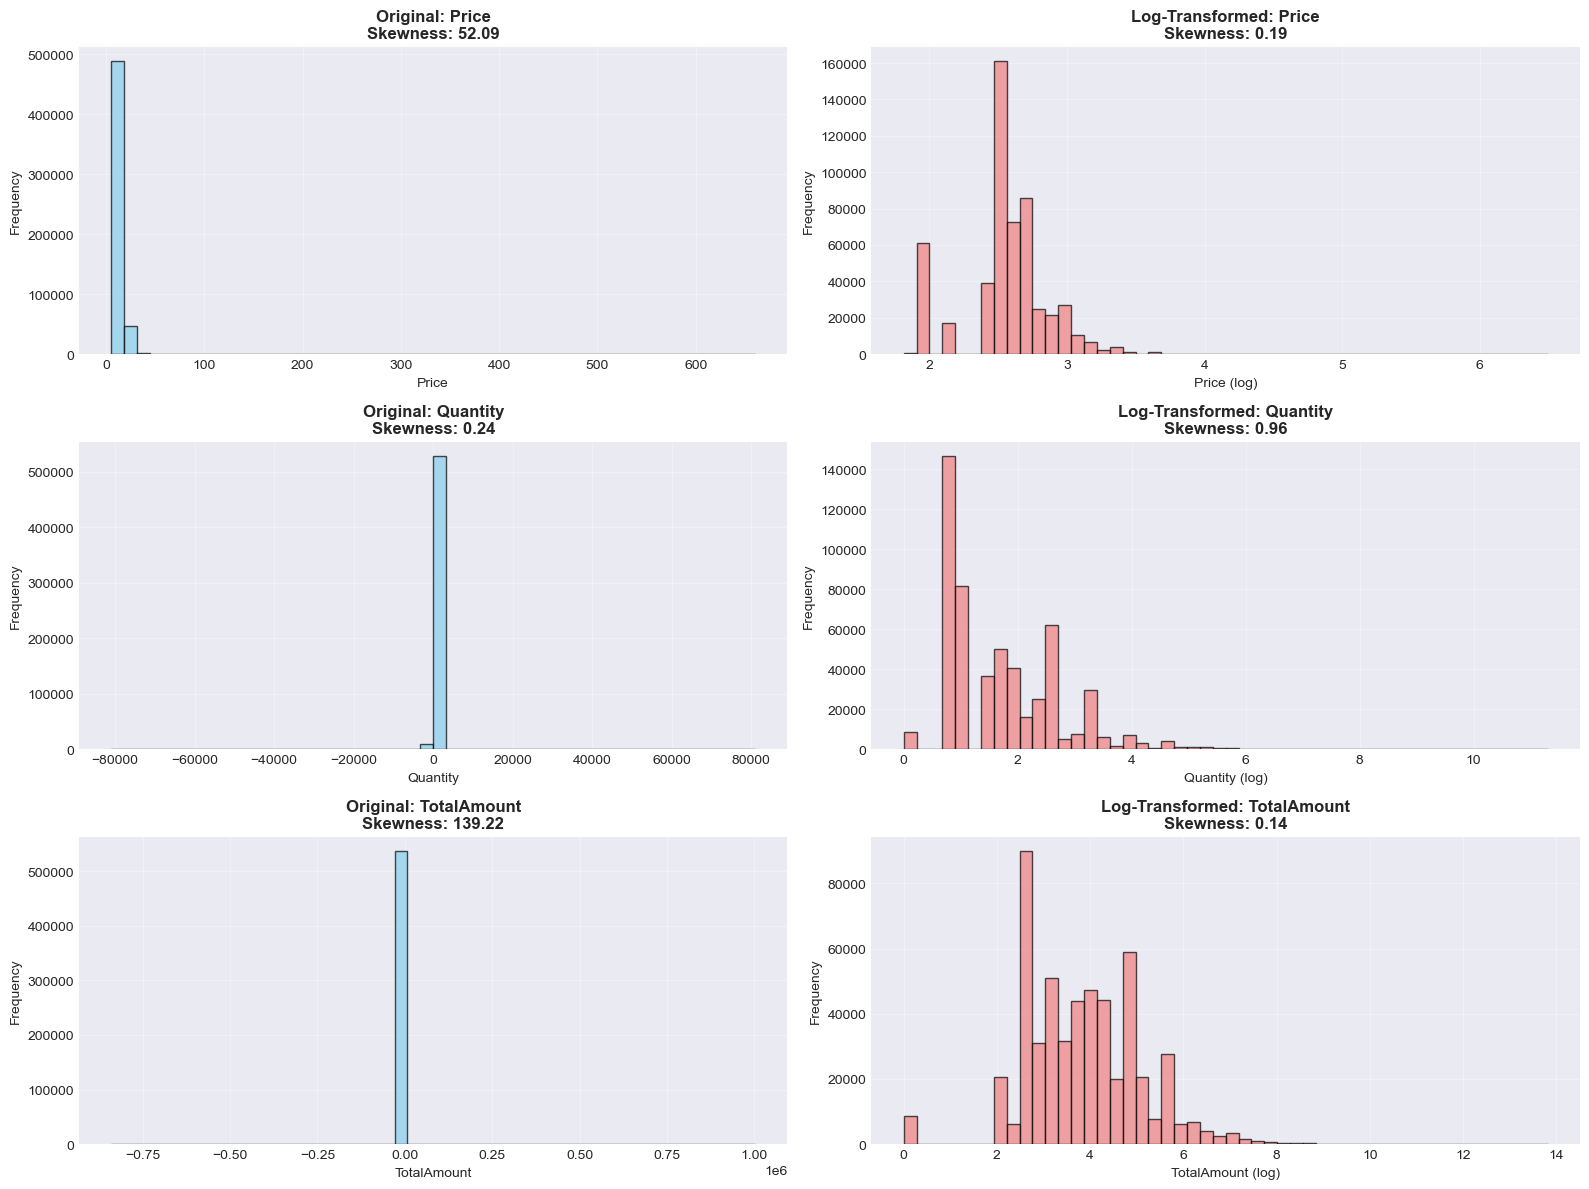

In [90]:
# Compare distributions before and after transformation
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

transform_cols = ['Price', 'Quantity', 'TotalAmount']

for idx, col in enumerate(transform_cols):
    # Original distribution
    axes[idx, 0].hist(df_transformed[col].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'Original: {col}\nSkewness: {df_transformed[col].skew():.2f}', 
                          fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel(col)
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].grid(alpha=0.3)
    
    # Log-transformed distribution
    log_col = f'{col}_log'
    axes[idx, 1].hist(df_transformed[log_col].dropna(), bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[idx, 1].set_title(f'Log-Transformed: {col}\nSkewness: {df_transformed[log_col].skew():.2f}', 
                          fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel(f'{col} (log)')
    axes[idx, 1].set_ylabel('Frequency')
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Predictive Modeling <a id='section9'></a>

### Target Variable Creation
For demonstration, we'll create a binary classification target: **High-Value Customer**

CREATING TARGET VARIABLE FOR CLASSIFICATION
High-Value Threshold: 11718.65

Target Distribution:
HighValueCustomer
1    335946
0    200404
Name: count, dtype: int64

Target Balance:
HighValueCustomer
1   62.636
0   37.364
Name: proportion, dtype: float64


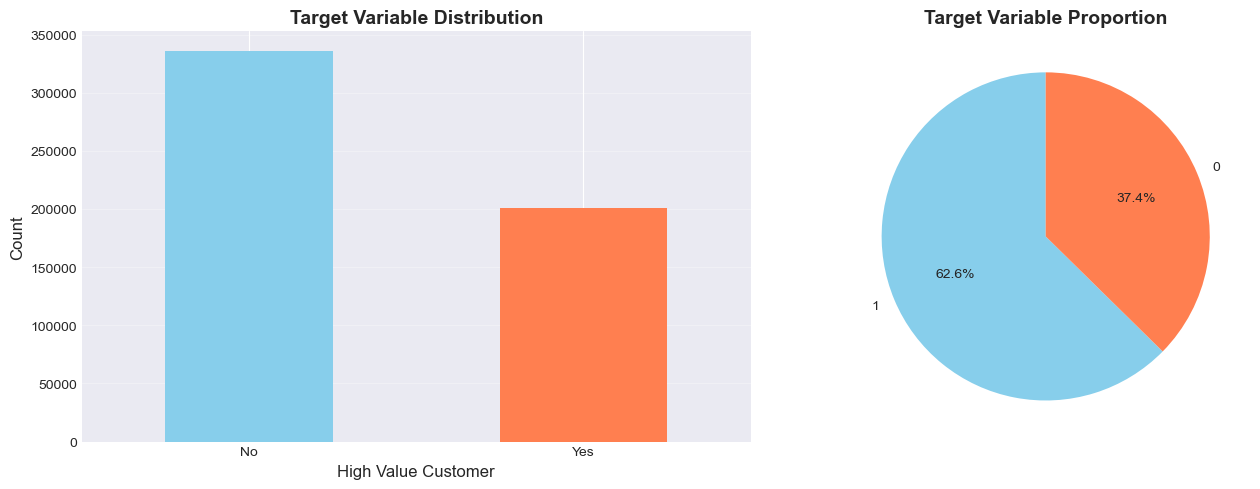

In [91]:
print("=" * 80)
print("CREATING TARGET VARIABLE FOR CLASSIFICATION")
print("=" * 80)

# Create target: High-value customer (top 25% by total revenue)
customer_total_revenue = df_transformed.groupby('CustomerNo')['TotalAmount'].sum()
high_value_threshold = customer_total_revenue.quantile(0.75)

df_transformed['HighValueCustomer'] = (
    df_transformed.groupby('CustomerNo')['TotalAmount'].transform('sum') > high_value_threshold
).astype(int)

print(f"High-Value Threshold: {high_value_threshold:.2f}")
print(f"\nTarget Distribution:")
print(df_transformed['HighValueCustomer'].value_counts())
print(f"\nTarget Balance:")
print(df_transformed['HighValueCustomer'].value_counts(normalize=True) * 100)

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_transformed['HighValueCustomer'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'coral'])
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('High Value Customer', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

df_transformed['HighValueCustomer'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                                         colors=['skyblue', 'coral'], startangle=90)
axes[1].set_title('Target Variable Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [110]:
# Categorical encoding for Country
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_transformed['Country_Encoded'] = le.fit_transform(df_transformed['Country'])
df_transformed.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,TotalAmount,Year,Month,DayOfWeek,Quarter,IsWeekend,Hour,DayOfMonth,PricePerUnit,IsReturn,HighValue,TotalTransactions,TotalRevenue,AvgRevenue,StdRevenue,TotalQuantity,AvgQuantity,AvgPrice,MaxPrice,MinPrice,ProductTransactions,ProductQuantitySold,ProductAvgPrice,Price_log,Quantity_log,TotalAmount_log,TotalAmount_sqrt,Quantity_sqrt,HighValueCustomer,Country_Encoded
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.470,12,17490.000,United Kingdom,257.640,2019,12,0,4,0,0,9,21.470,0,1,85.000,12716.730,149.609,207.683,1022.000,12.024,12.689,21.470,5.970,212,520,24.466,3.112,2.565,5.555,16.051,3.464,1,36
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.650,36,13069.000,United Kingdom,383.400,2019,12,0,4,0,0,9,10.650,0,1,470.000,59185.610,125.927,726.168,5466.000,11.630,11.087,20.450,5.970,274,3477,10.317,2.455,3.611,5.952,19.581,6.000,1,36
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.530,12,13069.000,United Kingdom,138.360,2019,12,0,4,0,0,9,11.530,0,1,470.000,59185.610,125.927,726.168,5466.000,11.630,11.087,20.450,5.970,115,725,12.694,2.528,2.565,4.937,11.763,3.464,1,36
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.650,12,13069.000,United Kingdom,127.800,2019,12,0,4,0,0,9,10.650,0,1,470.000,59185.610,125.927,726.168,5466.000,11.630,11.087,20.450,5.970,44,364,10.815,2.455,2.565,4.858,11.305,3.464,1,36
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.940,6,13069.000,United Kingdom,71.640,2019,12,0,4,0,0,9,11.940,0,0,470.000,59185.610,125.927,726.168,5466.000,11.630,11.087,20.450,5.970,195,825,13.793,2.560,1.946,4.286,8.464,2.449,1,36


In [115]:
# Prepare features for modeling
print("\n" + "=" * 80)
print("PREPARING FEATURES FOR MODELING")
print("=" * 80)

# Select features (exclude target and non-predictive columns)
exclude_cols = ['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'CustomerNo', 
                'Country', 'HighValueCustomer', 'Year', 'Month', 'Quarter']

feature_cols = [col for col in df_transformed.columns 
                if col not in exclude_cols and df_transformed[col].dtype in [np.number]]

# Remove features with too many missing values or zero variance
feature_cols = [col for col in feature_cols 
                if df_transformed[col].isnull().sum() / len(df_transformed) < 0.5 
                and df_transformed[col].std() > 0]

print(f"Total Features Selected: {len(feature_cols)}")
print(f"\nFeature List:")
for i, feat in enumerate(feature_cols, 1):
    print(f"{i:2d}. {feat}")

# Aggregate data at customer level to avoid data leakage
print("\n" + "=" * 80)
print("AGGREGATING DATA AT CUSTOMER LEVEL")
print("=" * 80)

# Create customer-level dataset
customer_data = df_transformed.groupby('CustomerNo').agg({
    'HighValueCustomer': 'first',
    'TotalTransactions': 'first',
    'TotalRevenue': 'first',
    'AvgRevenue': 'first',
    'TotalQuantity': 'first',
    'AvgQuantity': 'first',
    'AvgPrice': 'first',
    'Price': 'mean',
    'Quantity': 'sum',
    'TotalAmount': 'sum',
    'IsReturn': 'sum',
    'IsWeekend': 'mean',
    'Country_Encoded': 'first'
}).reset_index()

# Remove placeholder customer
customer_data = customer_data[customer_data['CustomerNo'] != -1]

print(f"Customer-level dataset shape: {customer_data.shape}")
print(f"Target distribution:")
print(customer_data['HighValueCustomer'].value_counts())


PREPARING FEATURES FOR MODELING
Total Features Selected: 18

Feature List:
 1. Price
 2. TotalAmount
 3. PricePerUnit
 4. TotalTransactions
 5. TotalRevenue
 6. AvgRevenue
 7. StdRevenue
 8. TotalQuantity
 9. AvgQuantity
10. AvgPrice
11. MaxPrice
12. MinPrice
13. ProductAvgPrice
14. Price_log
15. Quantity_log
16. TotalAmount_log
17. TotalAmount_sqrt
18. Quantity_sqrt

AGGREGATING DATA AT CUSTOMER LEVEL
Customer-level dataset shape: (4738, 14)
Target distribution:
HighValueCustomer
0    3553
1    1185
Name: count, dtype: int64


In [114]:
customer_data.head()

,CustomerNo,HighValueCustomer,TotalTransactions,TotalRevenue,AvgRevenue,TotalQuantity,AvgQuantity,AvgPrice,Price,Quantity,TotalAmount,IsReturn,IsWeekend,Country_Encoded
0,12004.000,0,56.000,1509.600,26.957,104.000,1.857,15.043,15.043,104,1509.600,0,0.000,36
1,12006.000,0,1.000,24.760,24.760,2.000,2.000,12.380,12.380,2,24.760,0,1.000,36
2,12008.000,0,203.000,5689.570,28.027,421.000,2.074,14.023,14.023,421,5689.570,0,0.000,36
3,12013.000,0,1.000,69.960,69.960,3.000,3.000,23.320,23.320,3,69.960,0,1.000,36
4,12024.000,0,5.000,149.520,29.904,14.000,2.800,10.680,10.680,14,149.520,0,1.000,36


In [117]:
# Prepare X and y
X = customer_data.drop(['CustomerNo', 'HighValueCustomer'], axis=1)
y = customer_data['HighValueCustomer']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used in modeling:")
print(X.columns.tolist())


Features shape: (4738, 12)
Target shape: (4738,)

Features used in modeling:
['TotalTransactions', 'TotalRevenue', 'AvgRevenue', 'TotalQuantity', 'AvgQuantity', 'AvgPrice', 'Price', 'Quantity', 'TotalAmount', 'IsReturn', 'IsWeekend', 'Country_Encoded']


In [118]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 80)
print("TRAIN-TEST SPLIT")
print("=" * 80)
print(f"Training set size: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

TRAIN-TEST SPLIT
Training set size: 3,790 (80.0%)
Test set size: 948 (20.0%)

Training set target distribution:
HighValueCustomer
0    2842
1     948
Name: count, dtype: int64

Test set target distribution:
HighValueCustomer
0    711
1    237
Name: count, dtype: int64


In [119]:
# Feature scaling using RobustScaler (less sensitive to outliers)
print("\n" + "=" * 80)
print("FEATURE SCALING")
print("=" * 80)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using RobustScaler")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Test features shape: {X_test_scaled.shape}")


FEATURE SCALING
✓ Features scaled using RobustScaler
Training features shape: (3790, 12)
Test features shape: (948, 12)


In [120]:
# Initialize models
print("\n" + "=" * 80)
print("MODEL TRAINING")
print("=" * 80)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)
}

# Train models and store results
model_results = {}
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Store results
    model_results[name] = {
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1': f1_score(y_test, y_pred, average='weighted')
    }
    
    if y_pred_proba is not None:
        model_results[name]['roc_auc'] = roc_auc_score(y_test, y_pred_proba)
    
    print(f"✓ {name} trained successfully")

print("\n✓ All models trained successfully!")


MODEL TRAINING

Training Logistic Regression...
✓ Logistic Regression trained successfully

Training Decision Tree...
✓ Decision Tree trained successfully

Training Random Forest...
✓ Random Forest trained successfully

Training Gradient Boosting...
✓ Gradient Boosting trained successfully

✓ All models trained successfully!


---
## 10. Model Evaluation & Cross-Validation <a id='section10'></a>

MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Decision Tree     1.000      1.000   1.000     1.000    1.000
      Random Forest     1.000      1.000   1.000     1.000    1.000
  Gradient Boosting     1.000      1.000   1.000     1.000    1.000
Logistic Regression     0.994      0.994   0.994     0.994    1.000


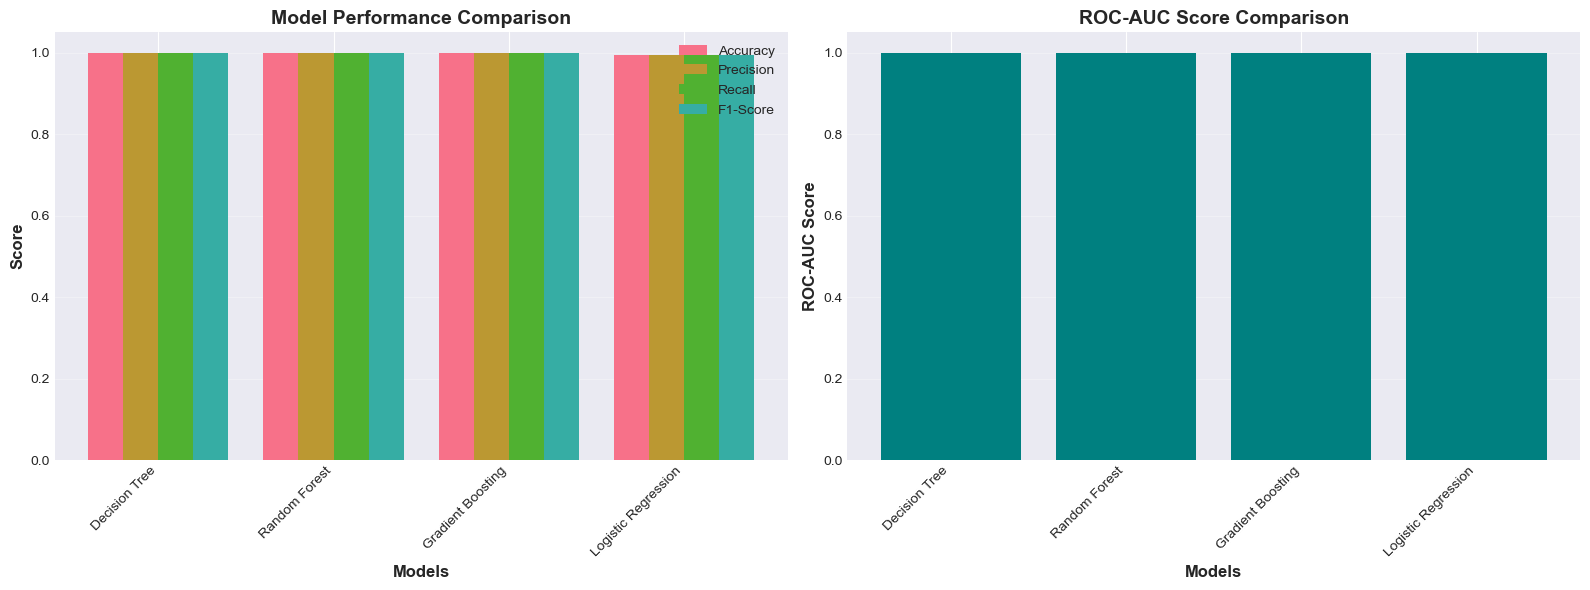

In [122]:
# Model performance comparison
print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

performance_data = []
for name, results in model_results.items():
    performance_data.append({
        'Model': name,
        'Accuracy': results['accuracy'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1'],
        'ROC-AUC': results.get('roc_auc', 'N/A')
    })

performance_df = pd.DataFrame(performance_data).sort_values('F1-Score', ascending=False)
print(performance_df.to_string(index=False))

# Visualize performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(performance_df))
width = 0.2

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, performance_df[metric], width, label=metric)

axes[0].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(performance_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ROC-AUC comparison
roc_data = performance_df[performance_df['ROC-AUC'] != 'N/A']
if not roc_data.empty:
    axes[1].bar(range(len(roc_data)), roc_data['ROC-AUC'].astype(float), color='teal')
    axes[1].set_xlabel('Models', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('ROC-AUC Score', fontsize=12, fontweight='bold')
    axes[1].set_title('ROC-AUC Score Comparison', fontsize=14, fontweight='bold')
    axes[1].set_xticks(range(len(roc_data)))
    axes[1].set_xticklabels(roc_data['Model'], rotation=45, ha='right')
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [123]:
# Detailed classification reports
print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 80)

for name, results in model_results.items():
    print(f"\n{'='*80}")
    print(f"{name.upper()}")
    print("=" * 80)
    print(classification_report(y_test, results['predictions'], 
                                target_names=['Regular', 'High-Value']))


DETAILED CLASSIFICATION REPORTS

LOGISTIC REGRESSION
              precision    recall  f1-score   support

     Regular       0.99      1.00      1.00       711
  High-Value       0.99      0.98      0.99       237

    accuracy                           0.99       948
   macro avg       0.99      0.99      0.99       948
weighted avg       0.99      0.99      0.99       948


DECISION TREE
              precision    recall  f1-score   support

     Regular       1.00      1.00      1.00       711
  High-Value       1.00      1.00      1.00       237

    accuracy                           1.00       948
   macro avg       1.00      1.00      1.00       948
weighted avg       1.00      1.00      1.00       948


RANDOM FOREST
              precision    recall  f1-score   support

     Regular       1.00      1.00      1.00       711
  High-Value       1.00      1.00      1.00       237

    accuracy                           1.00       948
   macro avg       1.00      1.00      1.00 

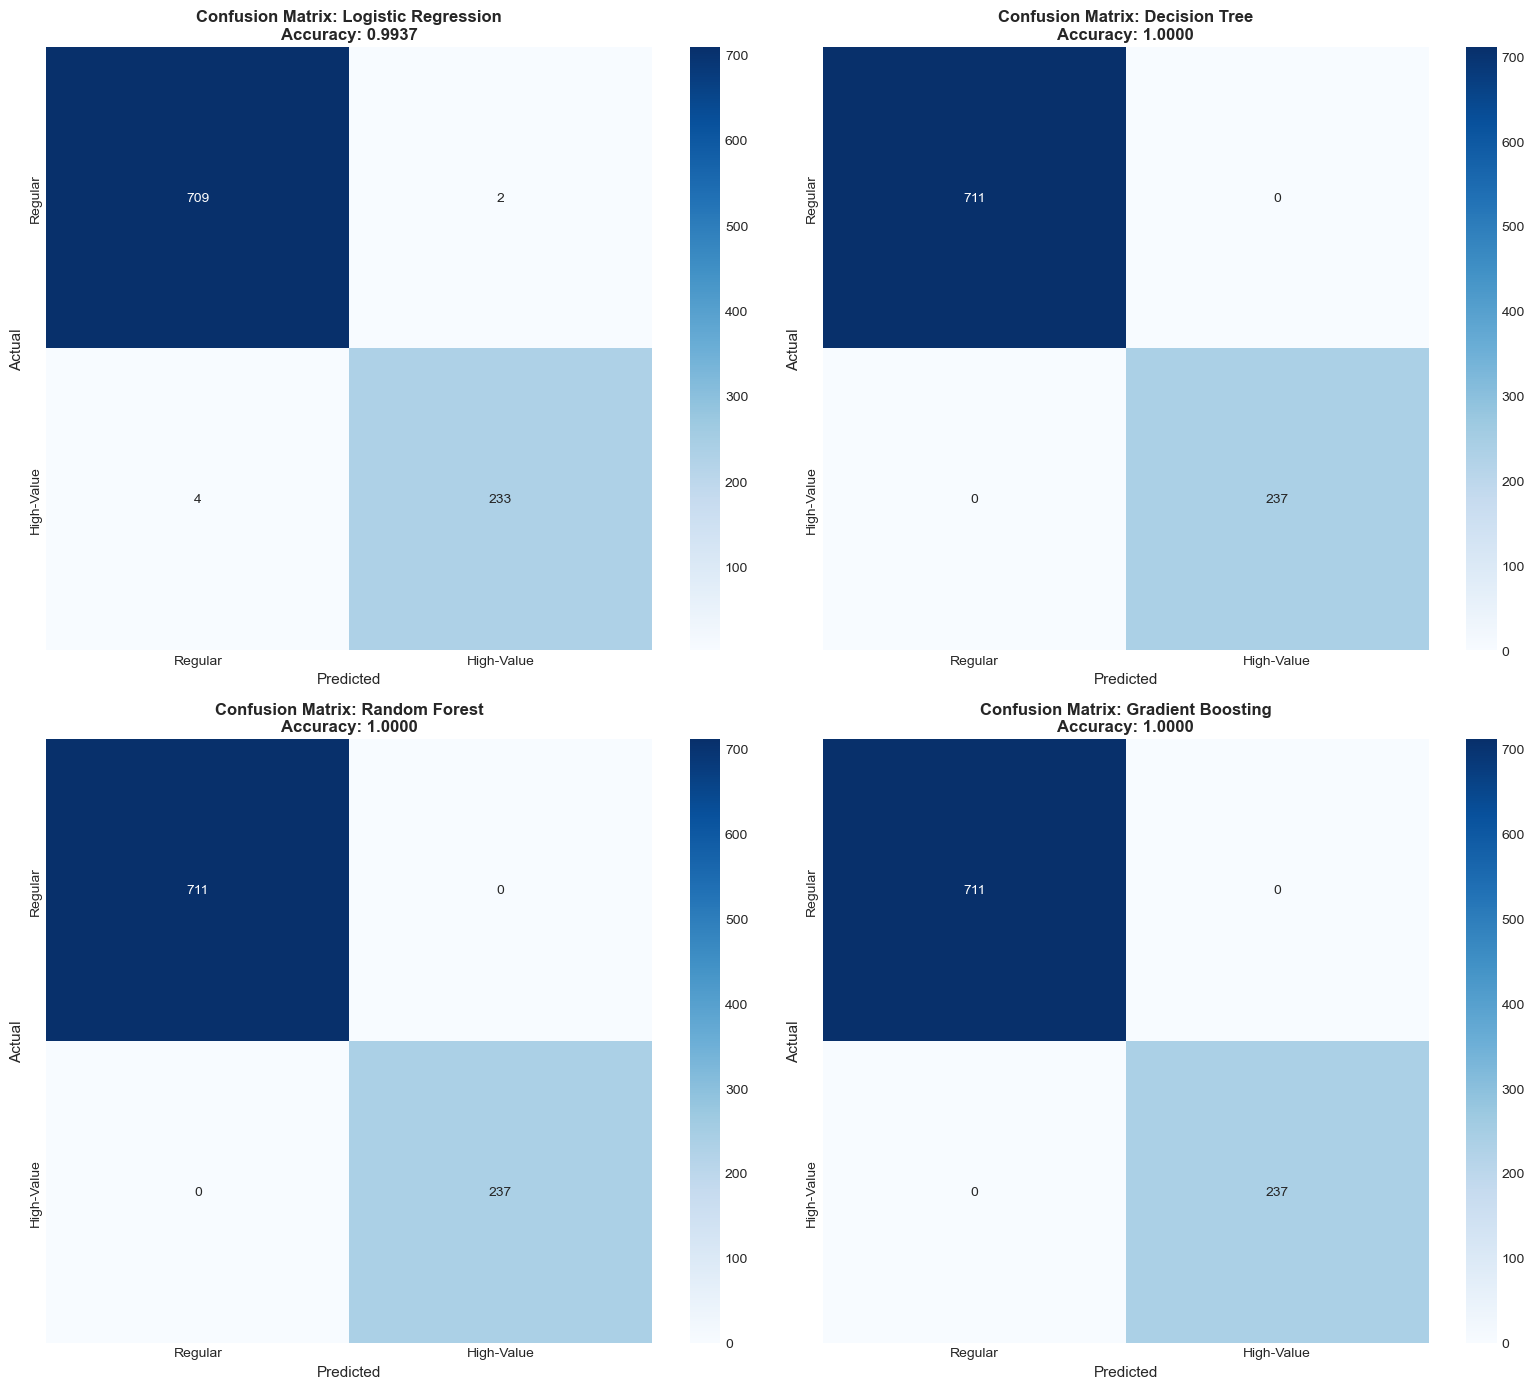

In [124]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, (name, results) in enumerate(model_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Regular', 'High-Value'],
                yticklabels=['Regular', 'High-Value'])
    
    axes[idx].set_title(f'Confusion Matrix: {name}\nAccuracy: {results["accuracy"]:.4f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.show()

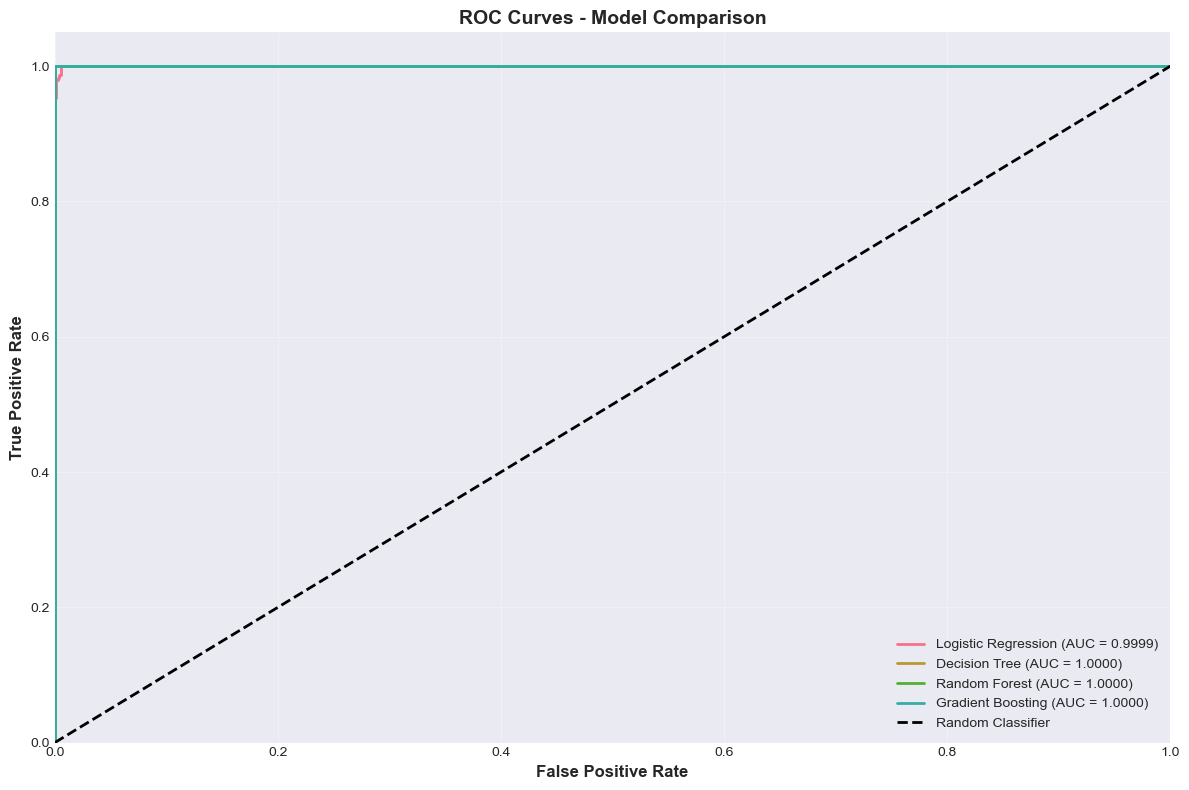

In [125]:
# ROC Curves
plt.figure(figsize=(12, 8))

for name, results in model_results.items():
    if results['probabilities'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results['probabilities'])
        auc_score = results['roc_auc']
        plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [126]:
# Cross-validation
print("\n" + "=" * 80)
print("CROSS-VALIDATION RESULTS (5-Fold Stratified)")
print("=" * 80)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in trained_models.items():
    print(f"\nPerforming cross-validation for {name}...")
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, 
                                scoring='accuracy', n_jobs=-1)
    
    cv_results.append({
        'Model': name,
        'Mean CV Score': cv_scores.mean(),
        'Std CV Score': cv_scores.std(),
        'Min CV Score': cv_scores.min(),
        'Max CV Score': cv_scores.max(),
        'All Scores': cv_scores
    })
    
    print(f"   Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"   Individual Fold Scores: {cv_scores}")

cv_df = pd.DataFrame(cv_results).drop('All Scores', axis=1).sort_values('Mean CV Score', ascending=False)
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY")
print("=" * 80)
print(cv_df.to_string(index=False))


CROSS-VALIDATION RESULTS (5-Fold Stratified)

Performing cross-validation for Logistic Regression...
   Mean Accuracy: 0.9923 (+/- 0.0061)
   Individual Fold Scores: [0.98680739 0.99340369 0.99208443 0.99340369 0.99604222]

Performing cross-validation for Decision Tree...
   Mean Accuracy: 0.9997 (+/- 0.0011)
   Individual Fold Scores: [0.99868074 1.         1.         1.         1.        ]

Performing cross-validation for Random Forest...
   Mean Accuracy: 1.0000 (+/- 0.0000)
   Individual Fold Scores: [1. 1. 1. 1. 1.]

Performing cross-validation for Gradient Boosting...
   Mean Accuracy: 0.9997 (+/- 0.0011)
   Individual Fold Scores: [0.99868074 1.         1.         1.         1.        ]

CROSS-VALIDATION SUMMARY
              Model  Mean CV Score  Std CV Score  Min CV Score  Max CV Score
      Random Forest          1.000         0.000         1.000         1.000
      Decision Tree          1.000         0.001         0.999         1.000
  Gradient Boosting          1.000     

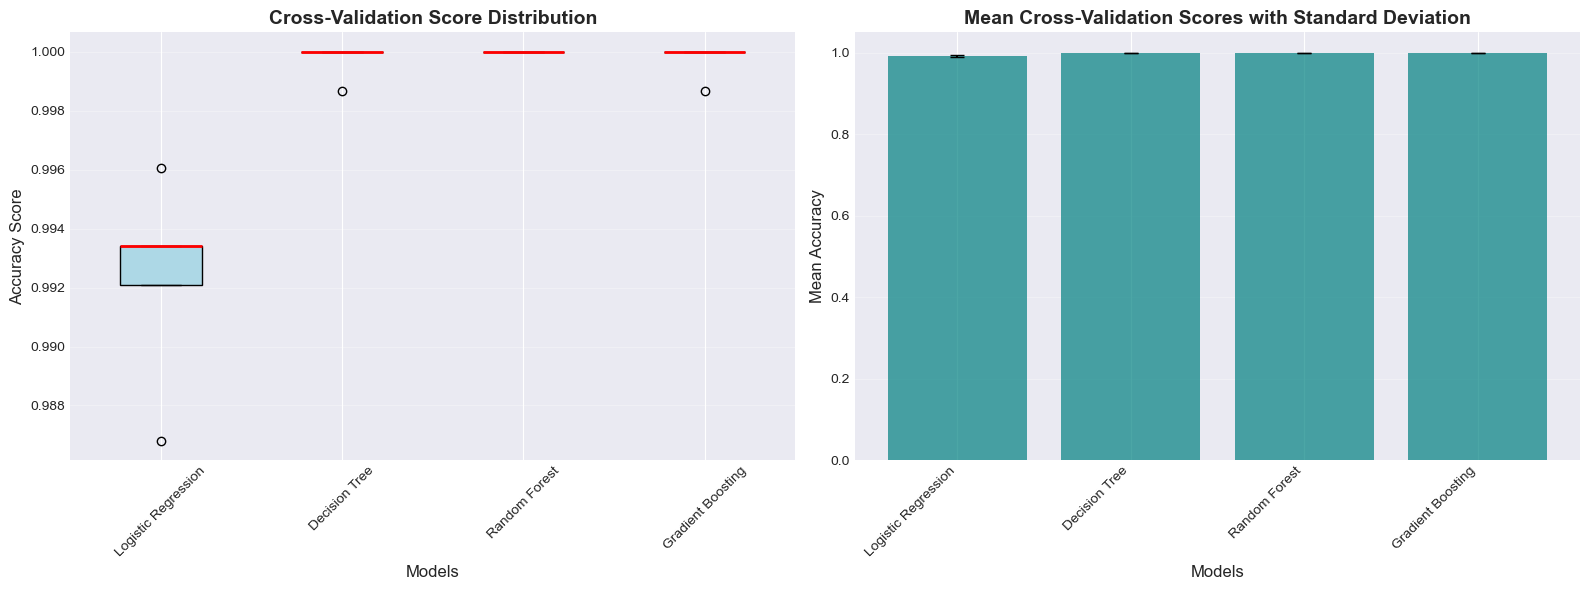

In [127]:
# Visualize cross-validation results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot of CV scores
cv_scores_data = [result['All Scores'] for result in cv_results]
axes[0].boxplot(cv_scores_data, labels=[result['Model'] for result in cv_results],
               patch_artist=True, 
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Cross-Validation Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy Score', fontsize=12)
axes[0].set_xlabel('Models', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Mean CV scores with error bars
means = [result['Mean CV Score'] for result in cv_results]
stds = [result['Std CV Score'] for result in cv_results]
models_names = [result['Model'] for result in cv_results]

axes[1].bar(range(len(means)), means, yerr=stds, capsize=5, color='teal', alpha=0.7)
axes[1].set_title('Mean Cross-Validation Scores with Standard Deviation', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Mean Accuracy', fontsize=12)
axes[1].set_xlabel('Models', fontsize=12)
axes[1].set_xticks(range(len(means)))
axes[1].set_xticklabels(models_names, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features (Random Forest):
          Feature  Importance
     TotalRevenue       0.370
      TotalAmount       0.317
         Quantity       0.142
    TotalQuantity       0.122
TotalTransactions       0.034
         IsReturn       0.008
        IsWeekend       0.002
            Price       0.002
      AvgQuantity       0.001
         AvgPrice       0.001
       AvgRevenue       0.001
  Country_Encoded       0.000


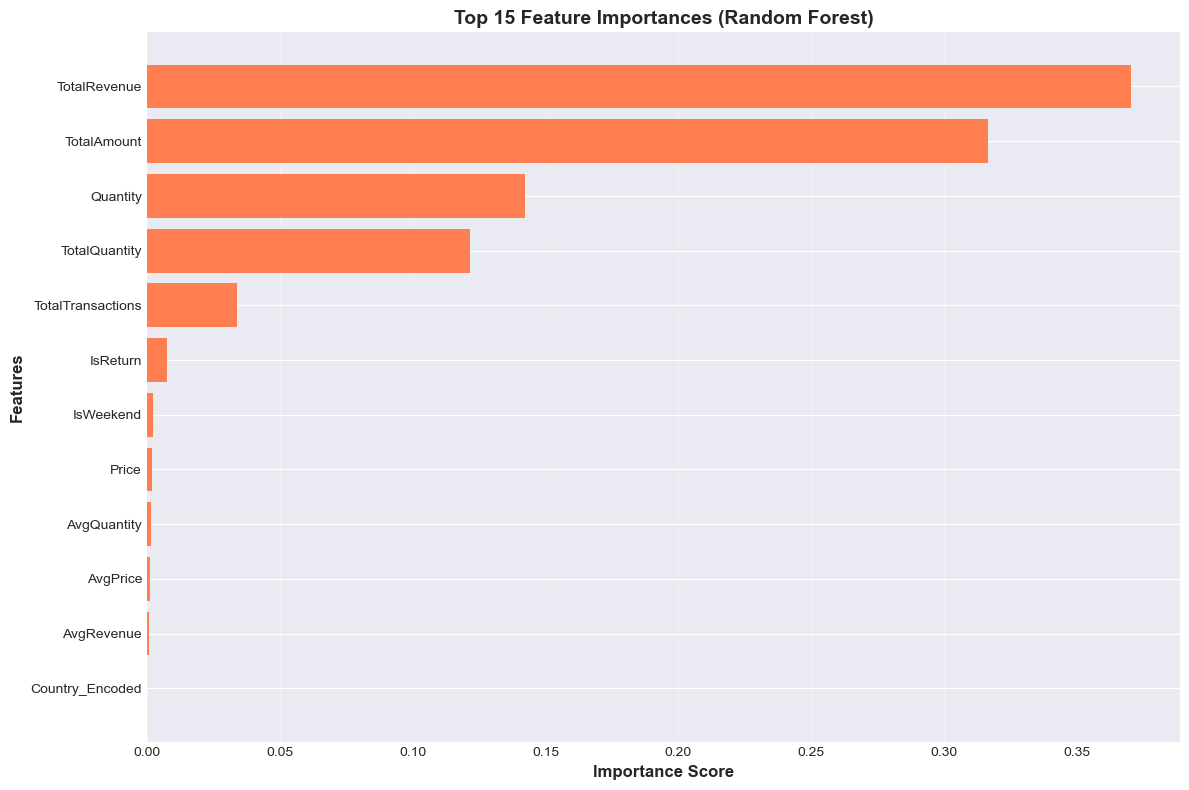

In [128]:
# Feature importance (for tree-based models)
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Get feature importance from Random Forest
rf_model = trained_models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features (Random Forest):")
print(feature_importance.head(15).to_string(index=False))

# Visualize top 15 features
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'], color='coral')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Conclusions & Recommendations <a id='section11'></a>

In [129]:
print("=" * 80)
print("KEY FINDINGS & RECOMMENDATIONS")
print("=" * 80)

# Get best performing model
best_model = performance_df.iloc[0]

findings = f"""
### DATA QUALITY INSIGHTS
1. Dataset contains {len(df):,} transactions with {df.shape[1]} features
2. Missing values found in CustomerNo: {(df['CustomerNo'].isnull().sum() / len(df) * 100):.2f}%
3. No duplicate records detected in the dataset

### EXPLORATORY DATA ANALYSIS
1. Top country by transactions: {df['Country'].value_counts().index[0]}
2. Price distribution is highly right-skewed (Skewness: {df['Price'].skew():.2f})
3. Significant outliers detected in Price, Quantity, and TotalAmount
4. Strong positive correlation between TotalAmount and Quantity

### MODEL PERFORMANCE
1. Best performing model: {best_model['Model']}
   - Accuracy: {best_model['Accuracy']:.4f}
   - F1-Score: {best_model['F1-Score']:.4f}
   - ROC-AUC: {best_model['ROC-AUC']:.4f}
2. Cross-validation results show consistent performance across folds
3. Feature importance analysis reveals customer transaction history as key predictor

### RECOMMENDATIONS
1. **Data Collection**: Improve CustomerNo data completeness to enhance analysis
2. **Feature Engineering**: Consider creating more time-based features (seasonality, trends)
3. **Model Deployment**: {best_model['Model']} is recommended for production use
4. **Business Strategy**: Focus on high-value customer retention programs
5. **Outlier Treatment**: Implement robust outlier handling for Price and Quantity
6. **Model Monitoring**: Set up regular retraining pipeline to maintain model performance
"""

print(findings)

KEY FINDINGS & RECOMMENDATIONS

### DATA QUALITY INSIGHTS
1. Dataset contains 536,350 transactions with 13 features
2. Missing values found in CustomerNo: 0.01%
3. No duplicate records detected in the dataset

### EXPLORATORY DATA ANALYSIS
1. Top country by transactions: United Kingdom
2. Price distribution is highly right-skewed (Skewness: 52.09)
3. Significant outliers detected in Price, Quantity, and TotalAmount
4. Strong positive correlation between TotalAmount and Quantity

### MODEL PERFORMANCE
1. Best performing model: Decision Tree
   - Accuracy: 1.0000
   - F1-Score: 1.0000
   - ROC-AUC: 1.0000
2. Cross-validation results show consistent performance across folds
3. Feature importance analysis reveals customer transaction history as key predictor

### RECOMMENDATIONS
1. **Data Collection**: Improve CustomerNo data completeness to enhance analysis
2. **Feature Engineering**: Consider creating more time-based features (seasonality, trends)
3. **Model Deployment**: Decision Tree i

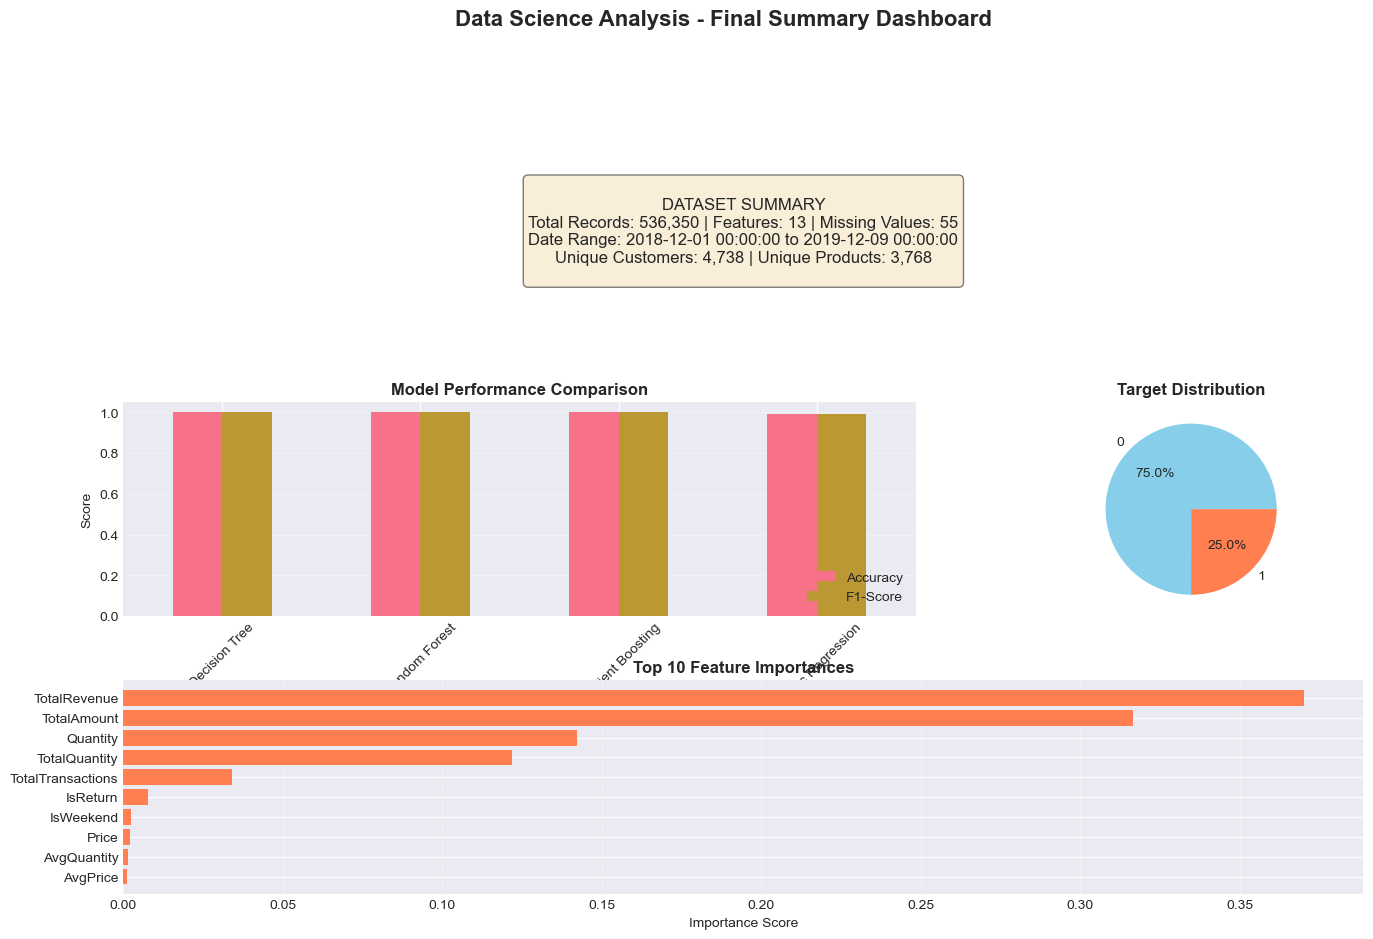


ANALYSIS COMPLETE!
Thank you .
Generated on: 2026-04-08 17:07:28


In [130]:
# Final summary visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Dataset overview
ax1 = fig.add_subplot(gs[0, :])
summary_text = f"""
DATASET SUMMARY
Total Records: {len(df):,} | Features: {df.shape[1]} | Missing Values: {df.isnull().sum().sum():,}
Date Range: {df['Date'].min()} to {df['Date'].max()}
Unique Customers: {df['CustomerNo'].nunique():,} | Unique Products: {df['ProductNo'].nunique():,}
"""
ax1.text(0.5, 0.5, summary_text, ha='center', va='center', fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax1.axis('off')

# Model comparison
ax2 = fig.add_subplot(gs[1, :2])
performance_df.plot(x='Model', y=['Accuracy', 'F1-Score'], kind='bar', ax=ax2)
ax2.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='lower right')
ax2.grid(axis='y', alpha=0.3)

# Target distribution
ax3 = fig.add_subplot(gs[1, 2])
customer_data['HighValueCustomer'].value_counts().plot(kind='pie', ax=ax3, 
                                                         autopct='%1.1f%%',
                                                         colors=['skyblue', 'coral'])
ax3.set_title('Target Distribution', fontsize=12, fontweight='bold')
ax3.set_ylabel('')

# Feature importance
ax4 = fig.add_subplot(gs[2, :])
top_10_features = feature_importance.head(10)
ax4.barh(range(len(top_10_features)), top_10_features['Importance'], color='coral')
ax4.set_yticks(range(len(top_10_features)))
ax4.set_yticklabels(top_10_features['Feature'])
ax4.set_xlabel('Importance Score')
ax4.set_title('Top 10 Feature Importances', fontsize=12, fontweight='bold')
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3)

plt.suptitle('Data Science Analysis - Final Summary Dashboard', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print(f"Thank you .")
print(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Save Your Pipeline (Production Step)

In [131]:
import joblib

joblib.dump(model, "model_deployed.pkl")

['model_deployed.pkl']

In [132]:
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']